In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from data_profiling import ProfileReport
# 31.4s, 1m 2s, 46.9s, 37s, 14.9s 

## load dataset


In [5]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [6]:
df.drop(columns=["customerID"], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
originalShape=df.shape

In [12]:
originalShape

(7043, 20)

In [13]:
df[df.duplicated()==True]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [14]:
df.shape

(7043, 20)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(7021, 20)

In [17]:
df.dropna(inplace=True)

In [18]:
df.shape

(7010, 20)

## EDA


In [19]:

for columns in df.columns:
    if df[columns].dtype != "object":
        continue
    print(df[columns].value_counts(), "\n")

gender
Male      3535
Female    3475
Name: count, dtype: int64 

Partner
No     3617
Yes    3393
Name: count, dtype: int64 

Dependents
No     4911
Yes    2099
Name: count, dtype: int64 

PhoneService
Yes    6330
No      680
Name: count, dtype: int64 

MultipleLines
No                  3363
Yes                 2967
No phone service     680
Name: count, dtype: int64 

InternetService
Fiber optic    3090
DSL            2414
No             1506
Name: count, dtype: int64 

OnlineSecurity
No                     3489
Yes                    2015
No internet service    1506
Name: count, dtype: int64 

OnlineBackup
No                     3079
Yes                    2425
No internet service    1506
Name: count, dtype: int64 

DeviceProtection
No                     3086
Yes                    2418
No internet service    1506
Name: count, dtype: int64 

TechSupport
No                     3464
Yes                    2040
No internet service    1506
Name: count, dtype: int64 

StreamingTV
No       

<Axes: xlabel='tenure', ylabel='Density'>

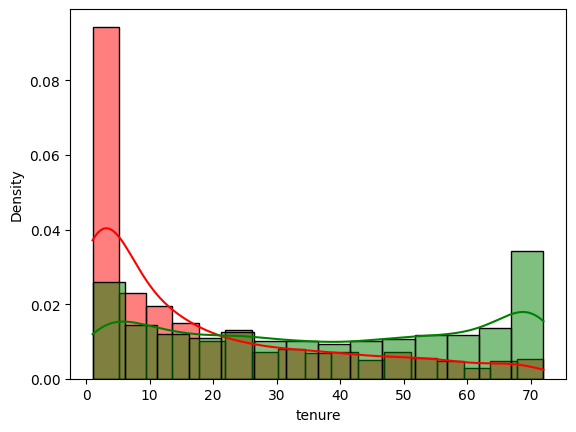

In [20]:
sns.histplot(x=df[df["Churn"]=="Yes"]["tenure"], kde=True, stat="density", color="red")
sns.histplot(x=df[df["Churn"]=="No"]["tenure"], kde=True, stat="density", color="green")

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

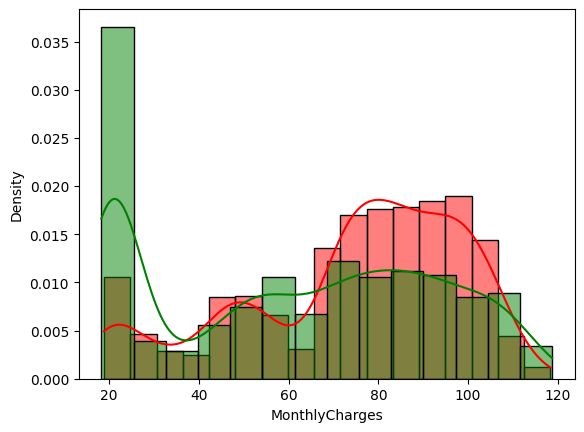

In [21]:
sns.histplot(df[df["Churn"]=="Yes"]["MonthlyCharges"],kde=True, color="red", stat="density")
sns.histplot(df[df["Churn"]=="No"]["MonthlyCharges"],kde=True, color="green", stat="density")

<Axes: xlabel='TotalCharges', ylabel='Density'>

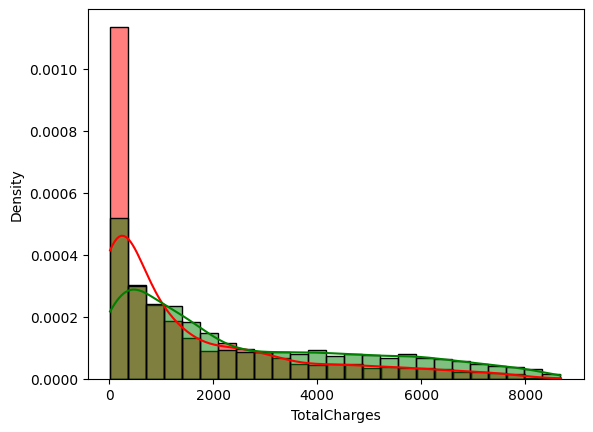

In [22]:
sns.histplot(df[df["Churn"]=="Yes"]["TotalCharges"],kde=True, color="red", bins=25, stat="density")
sns.histplot(df[df["Churn"]=="No"]["TotalCharges"],kde=True, color="green", bins=25, stat="density")

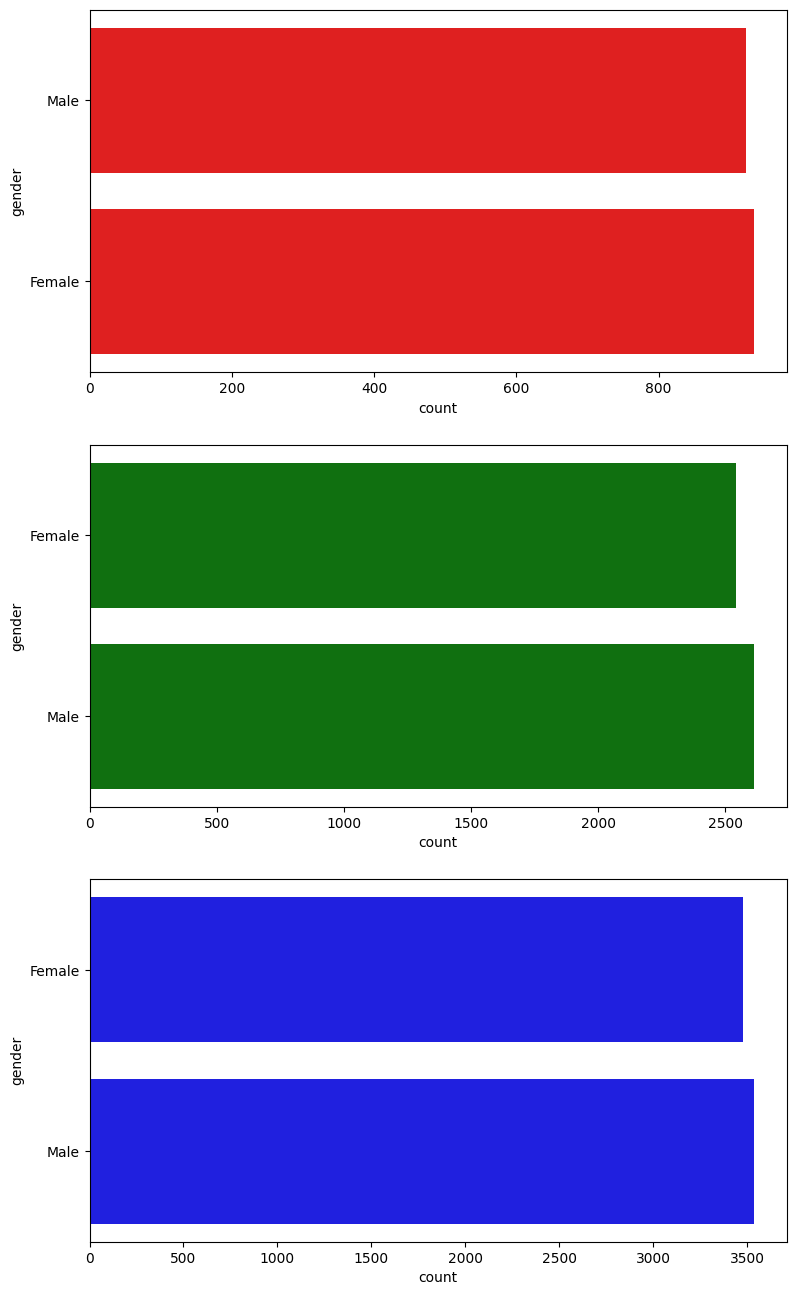

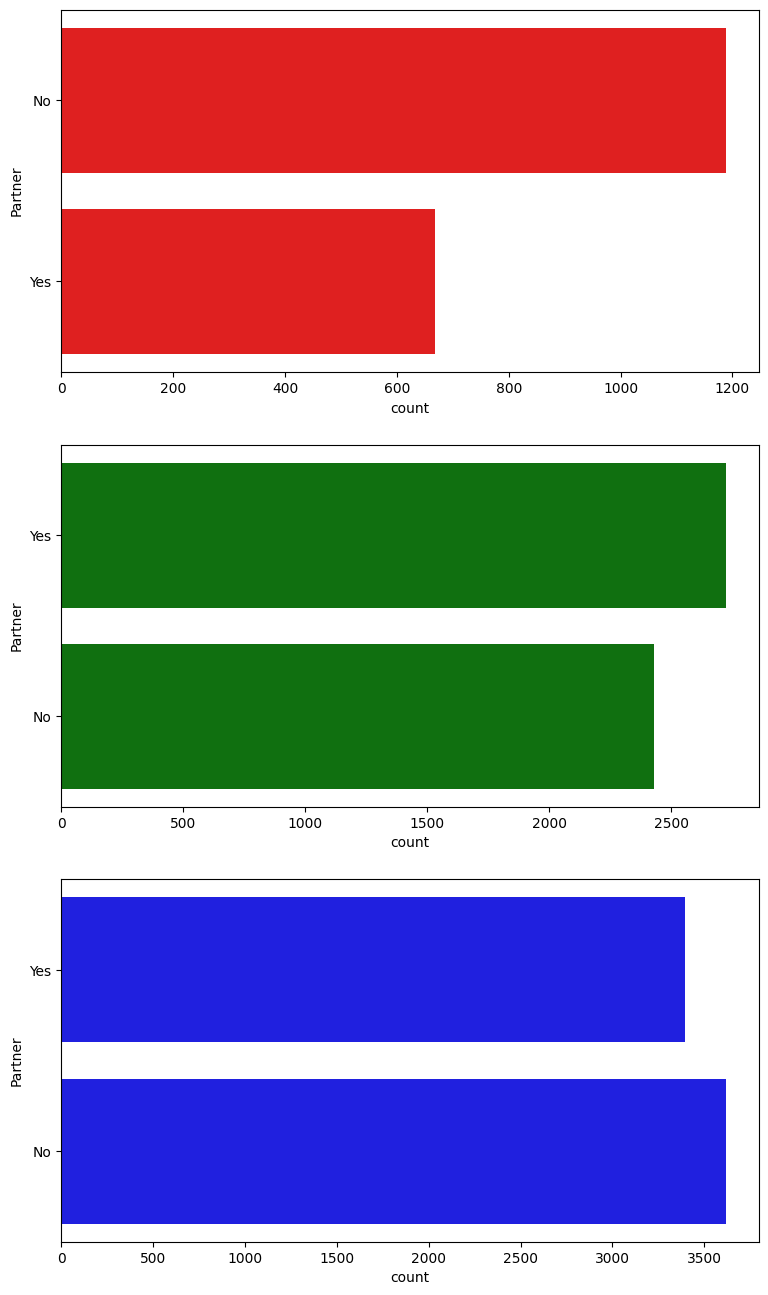

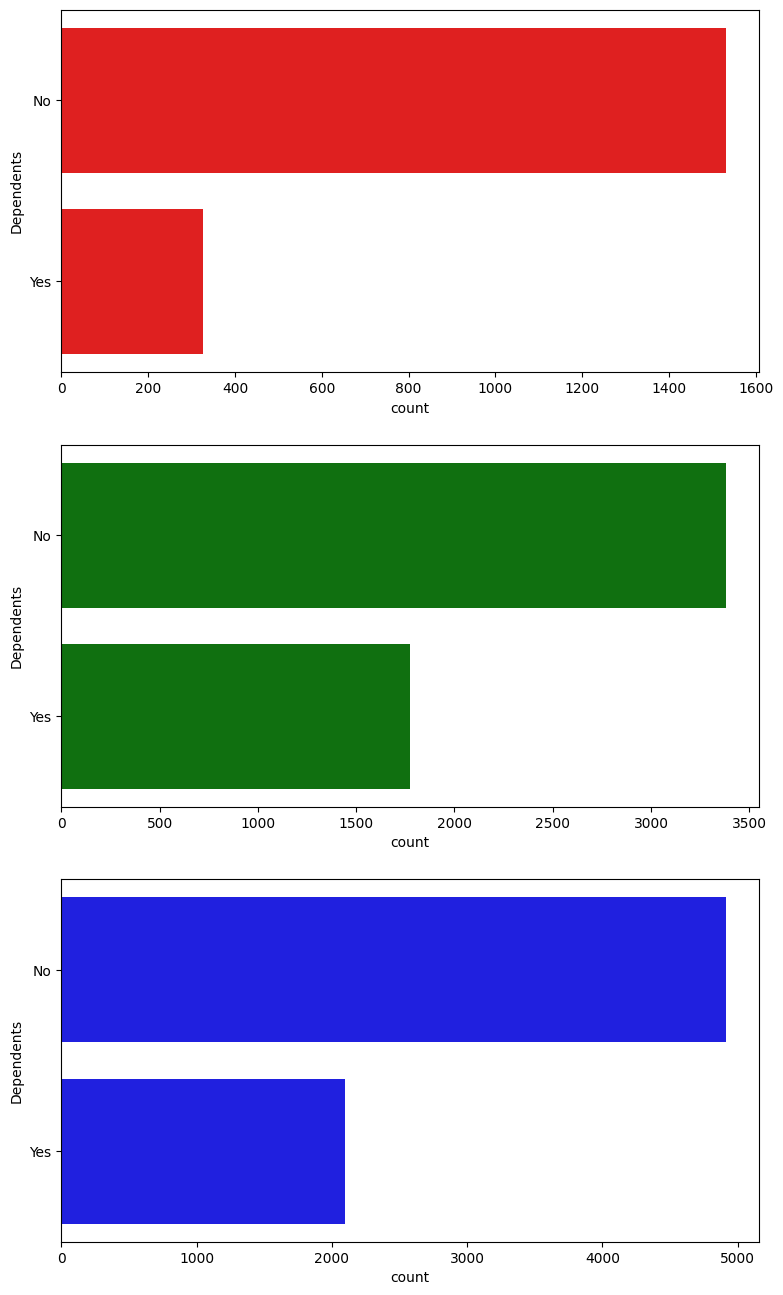

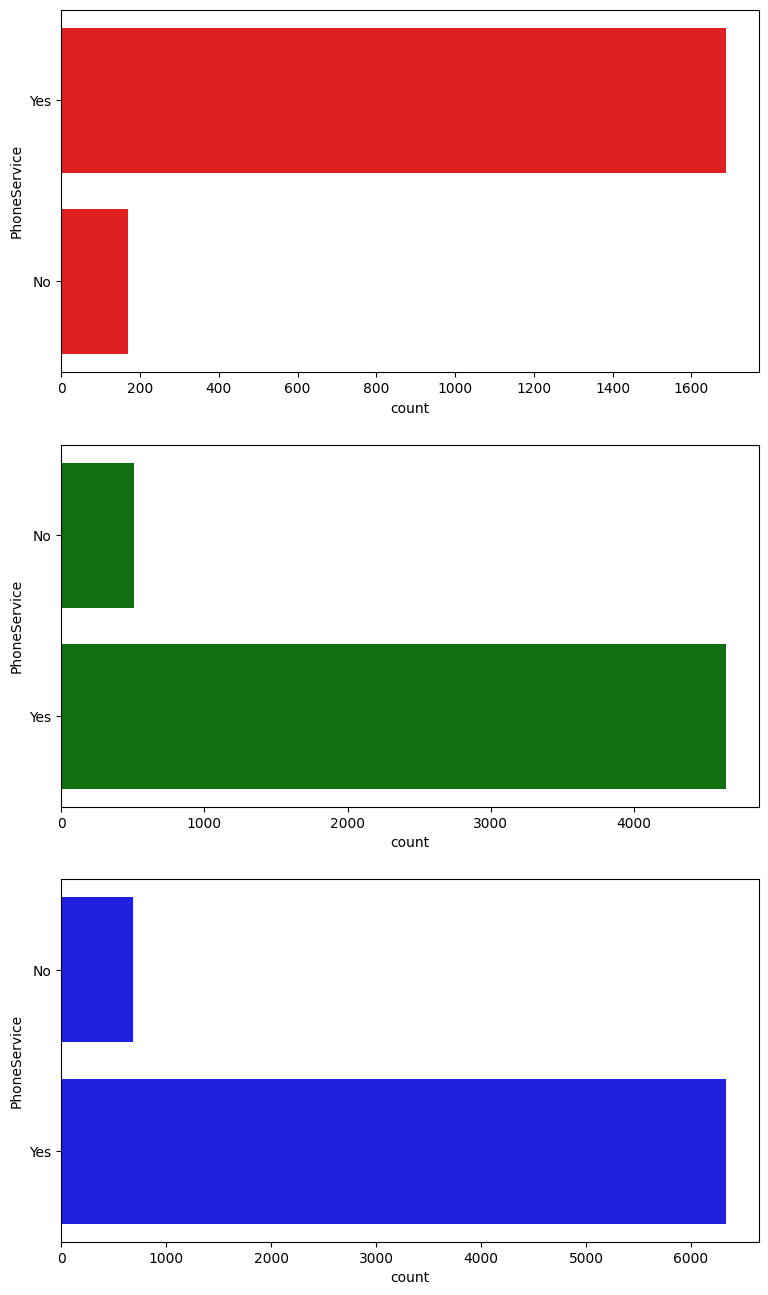

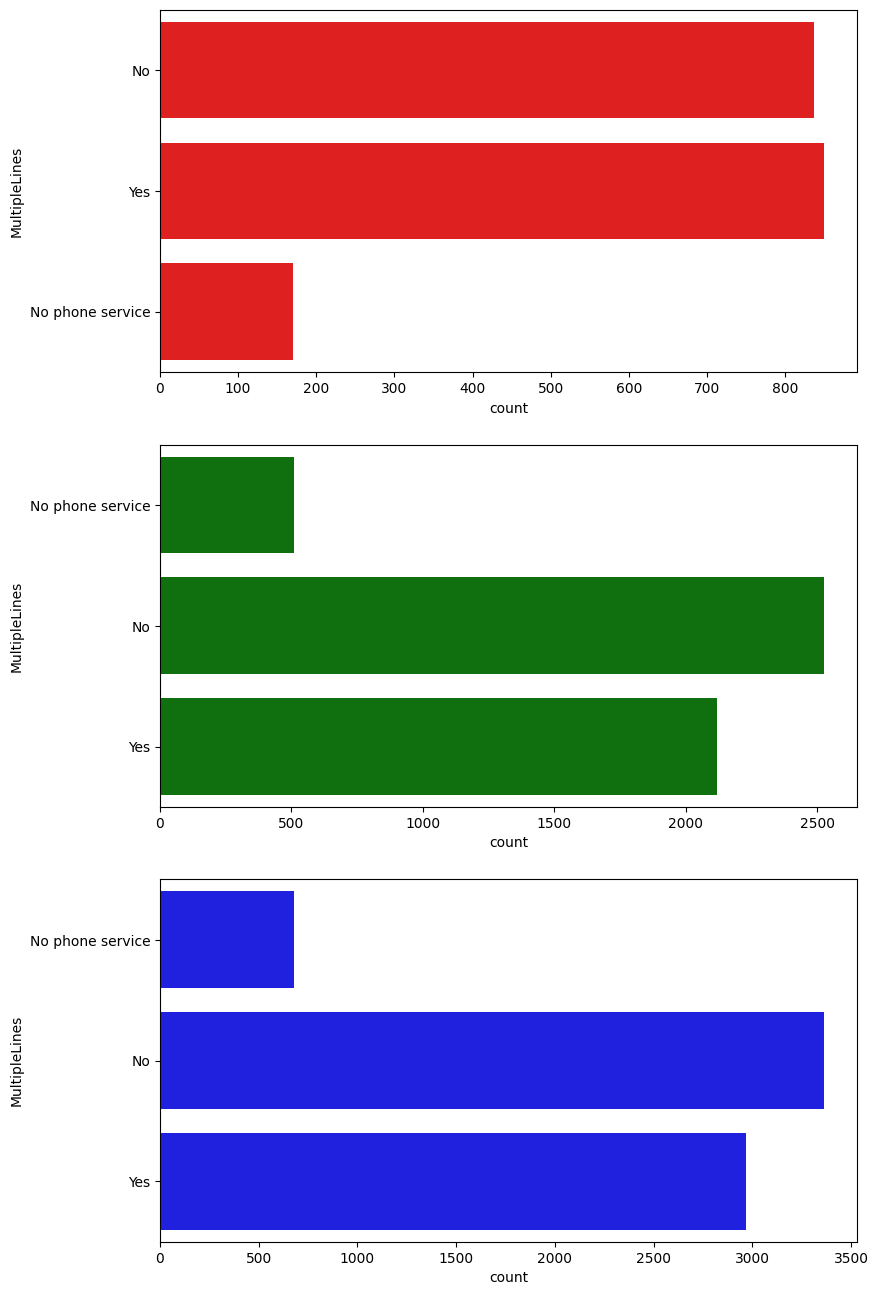

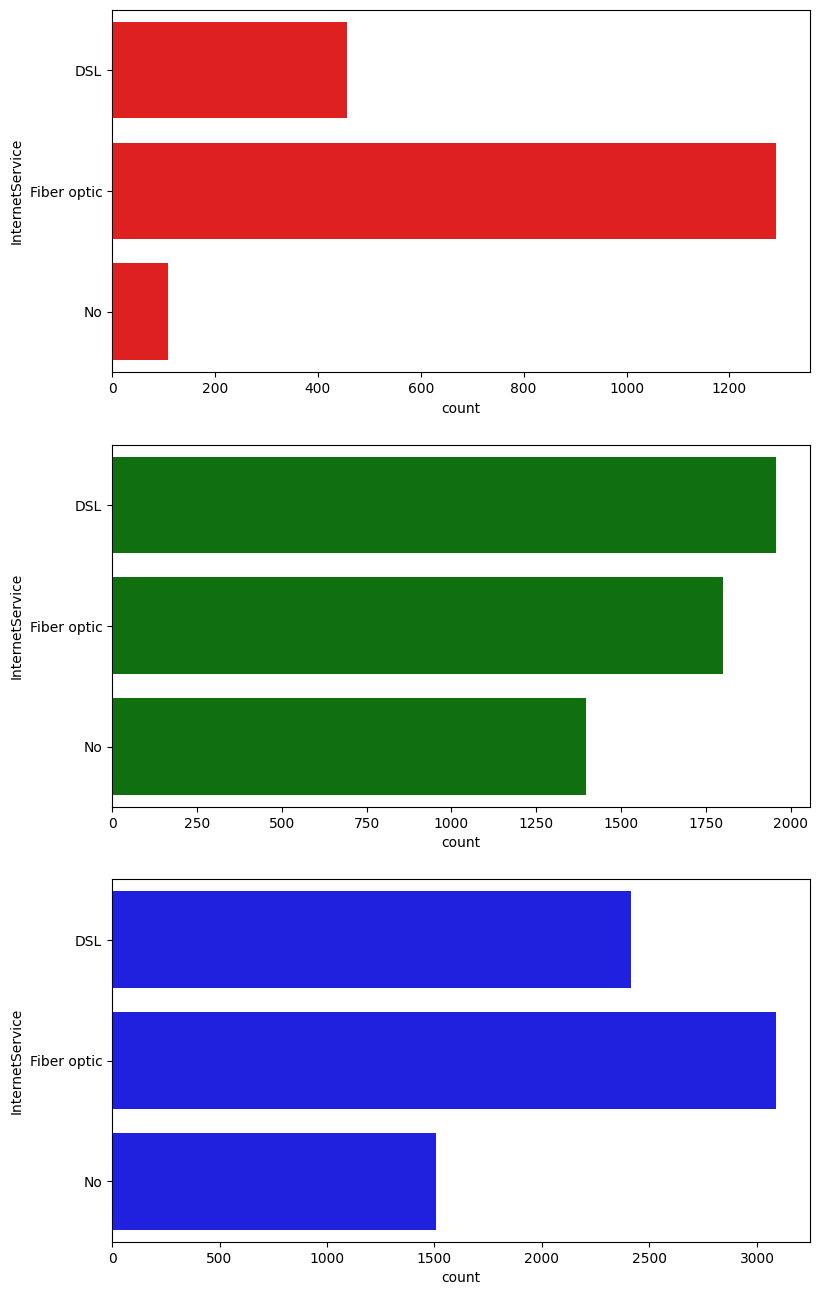

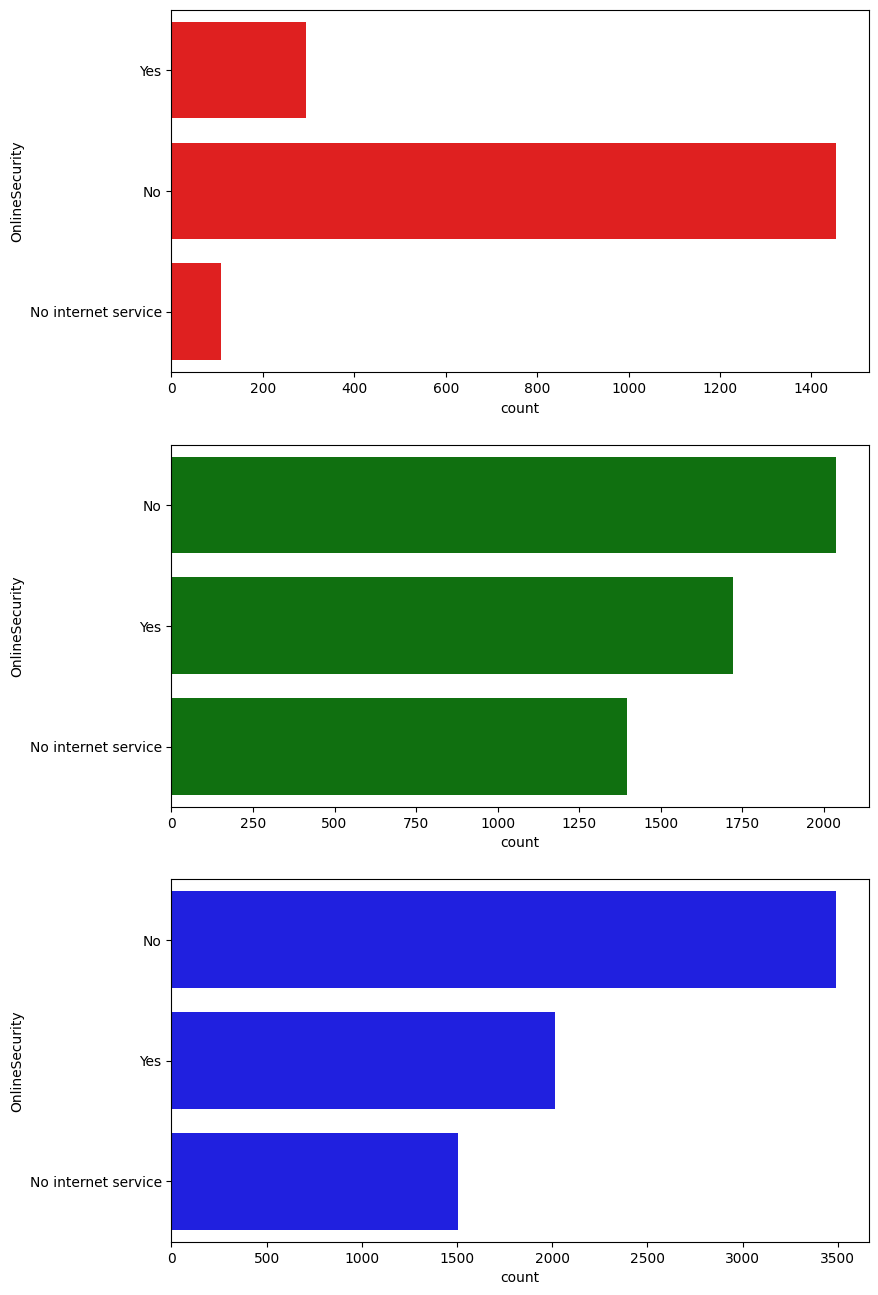

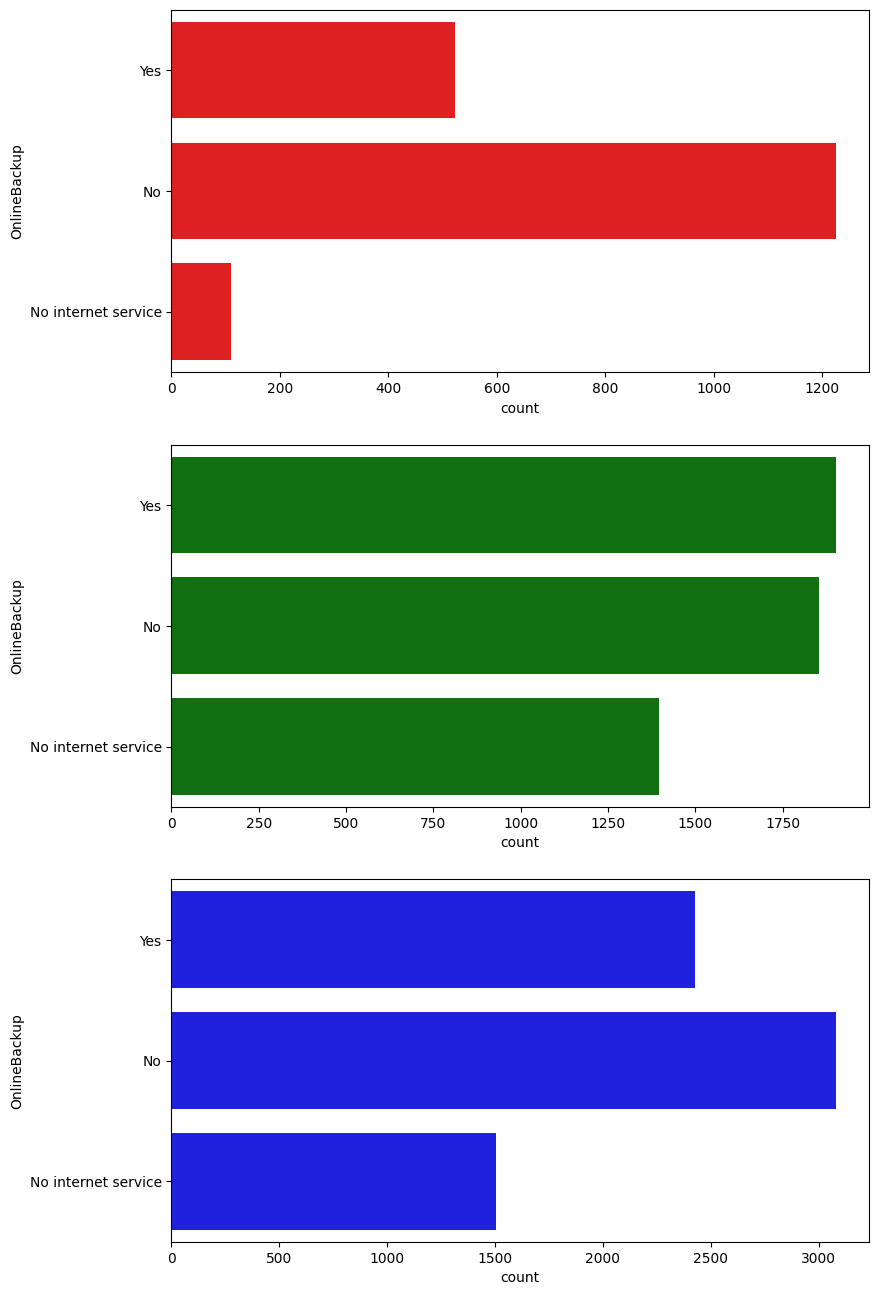

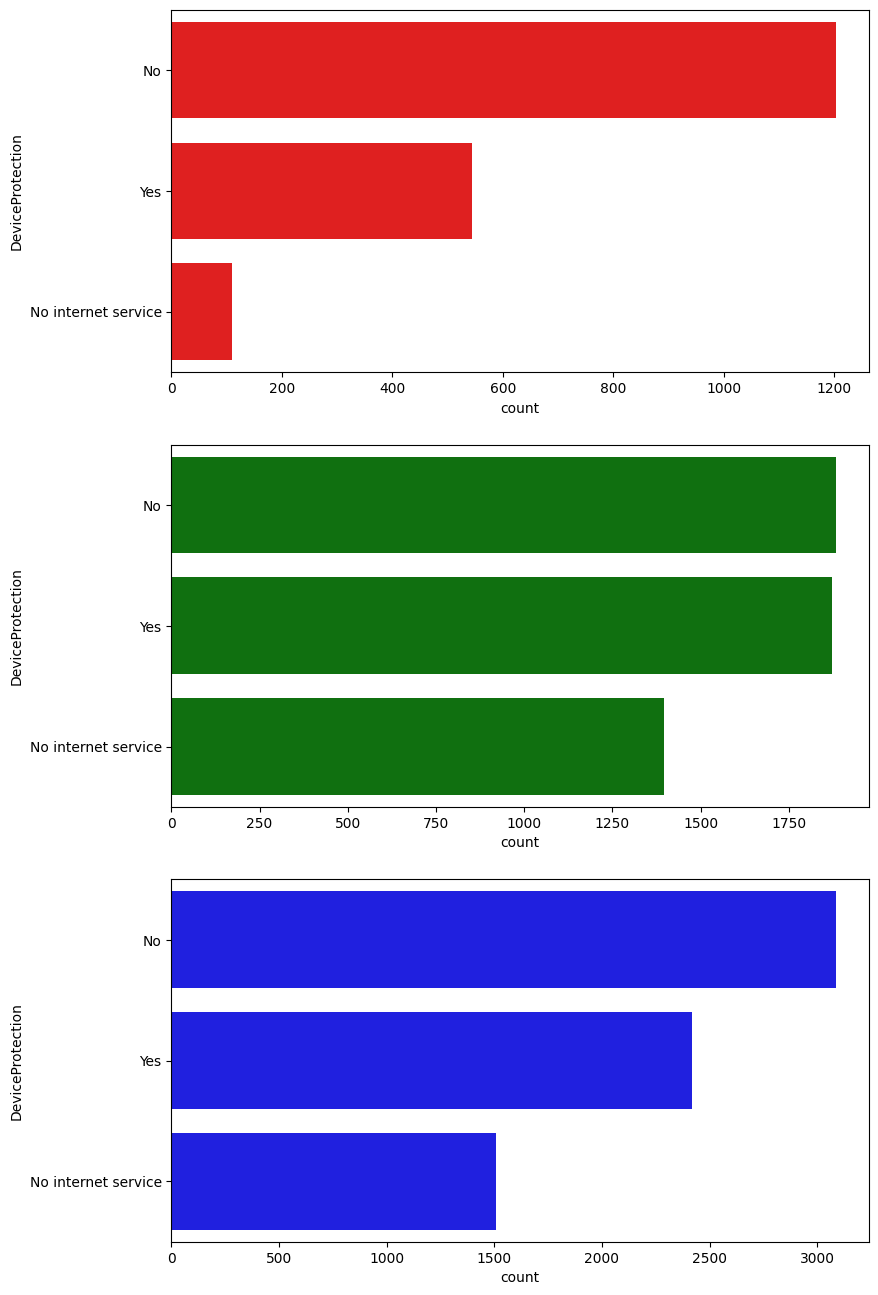

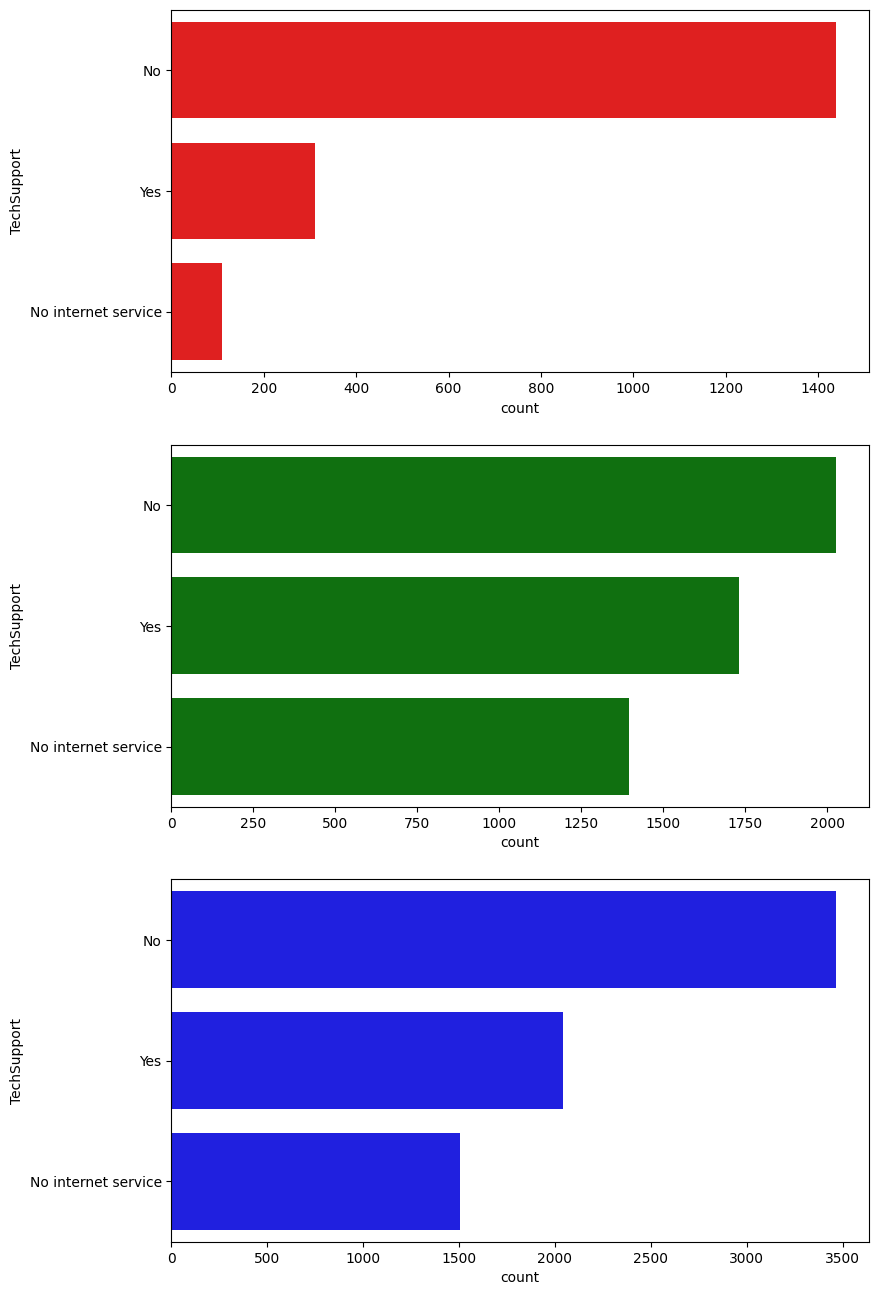

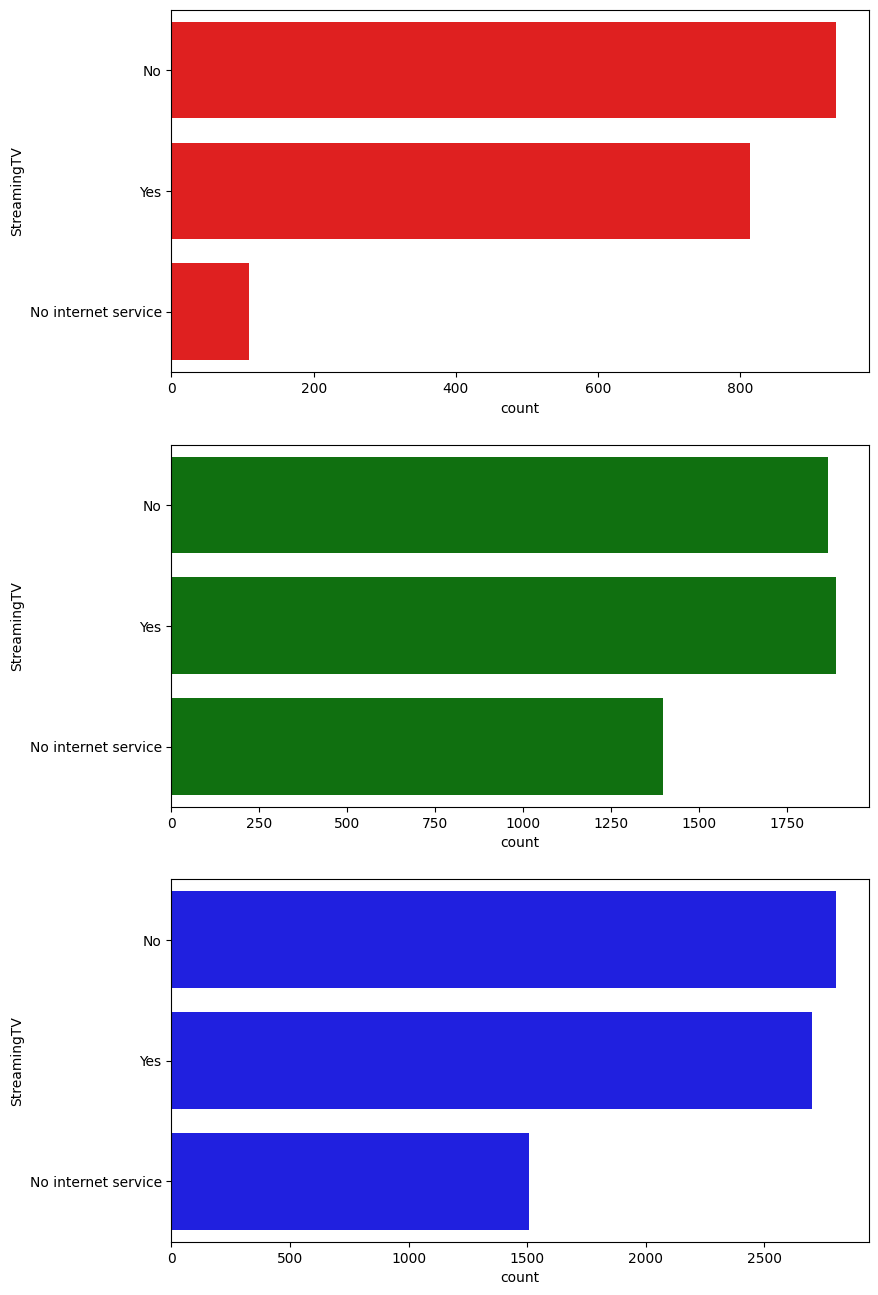

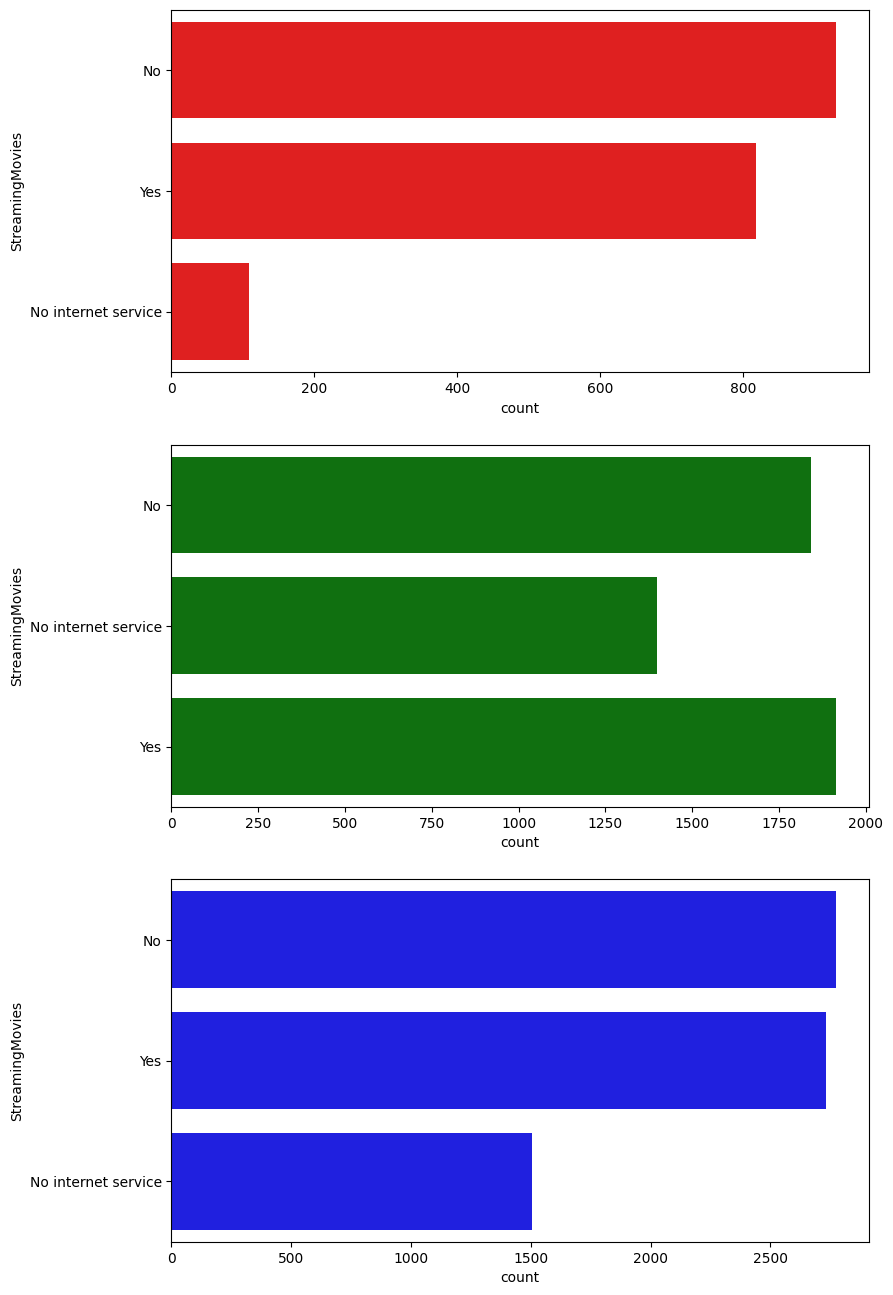

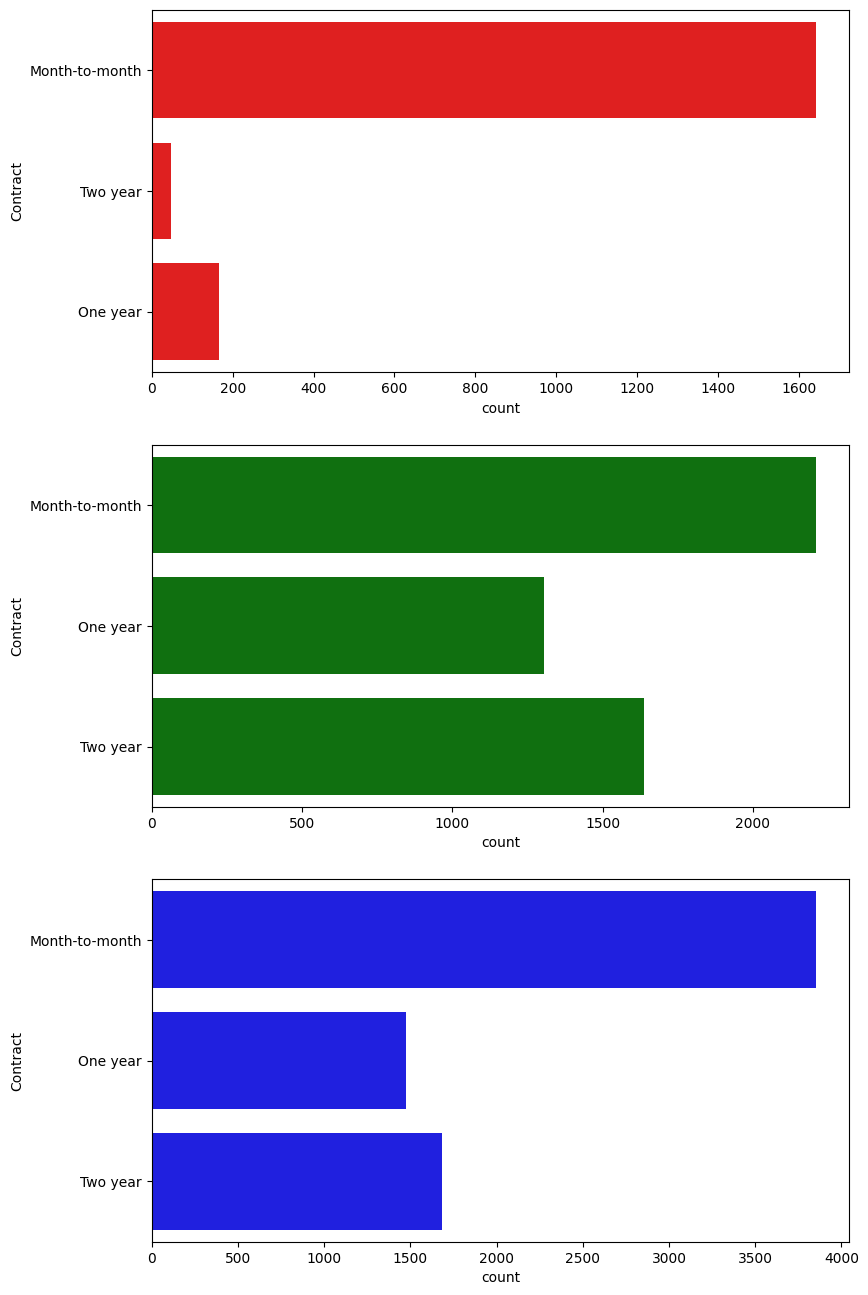

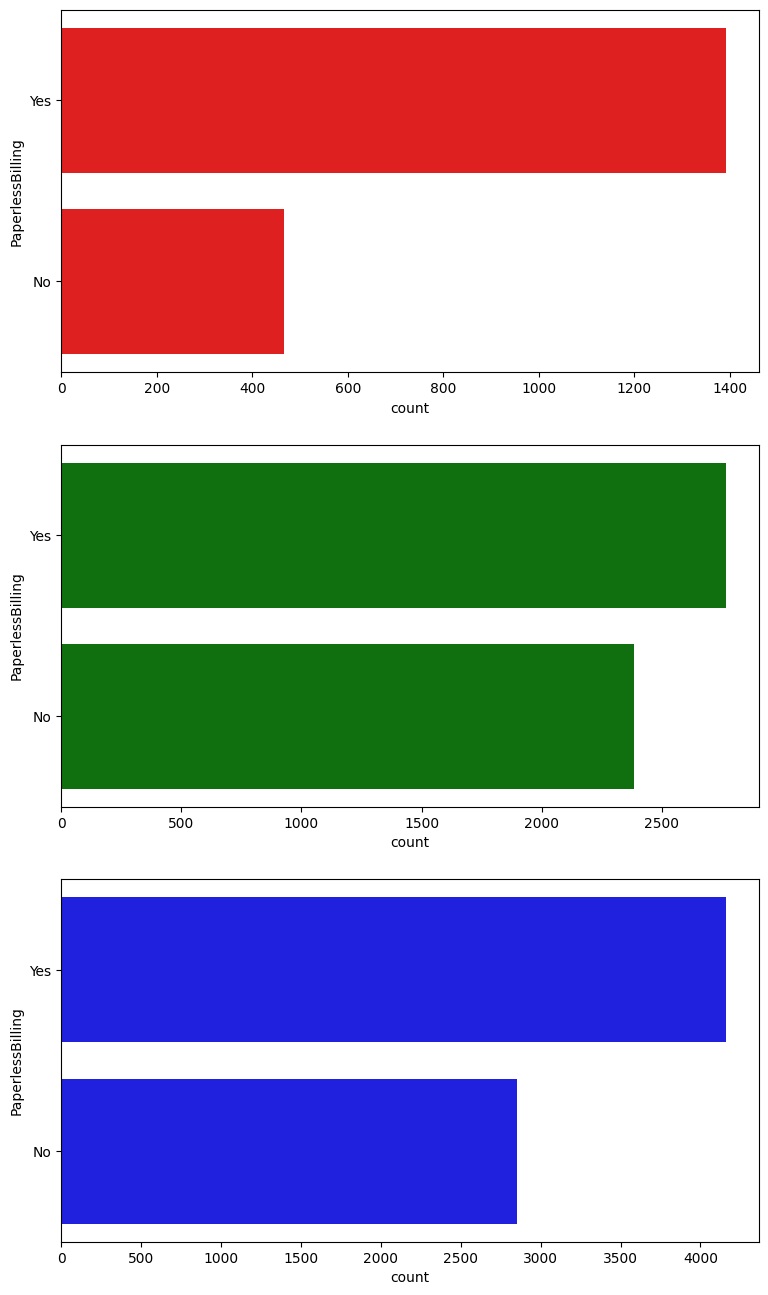

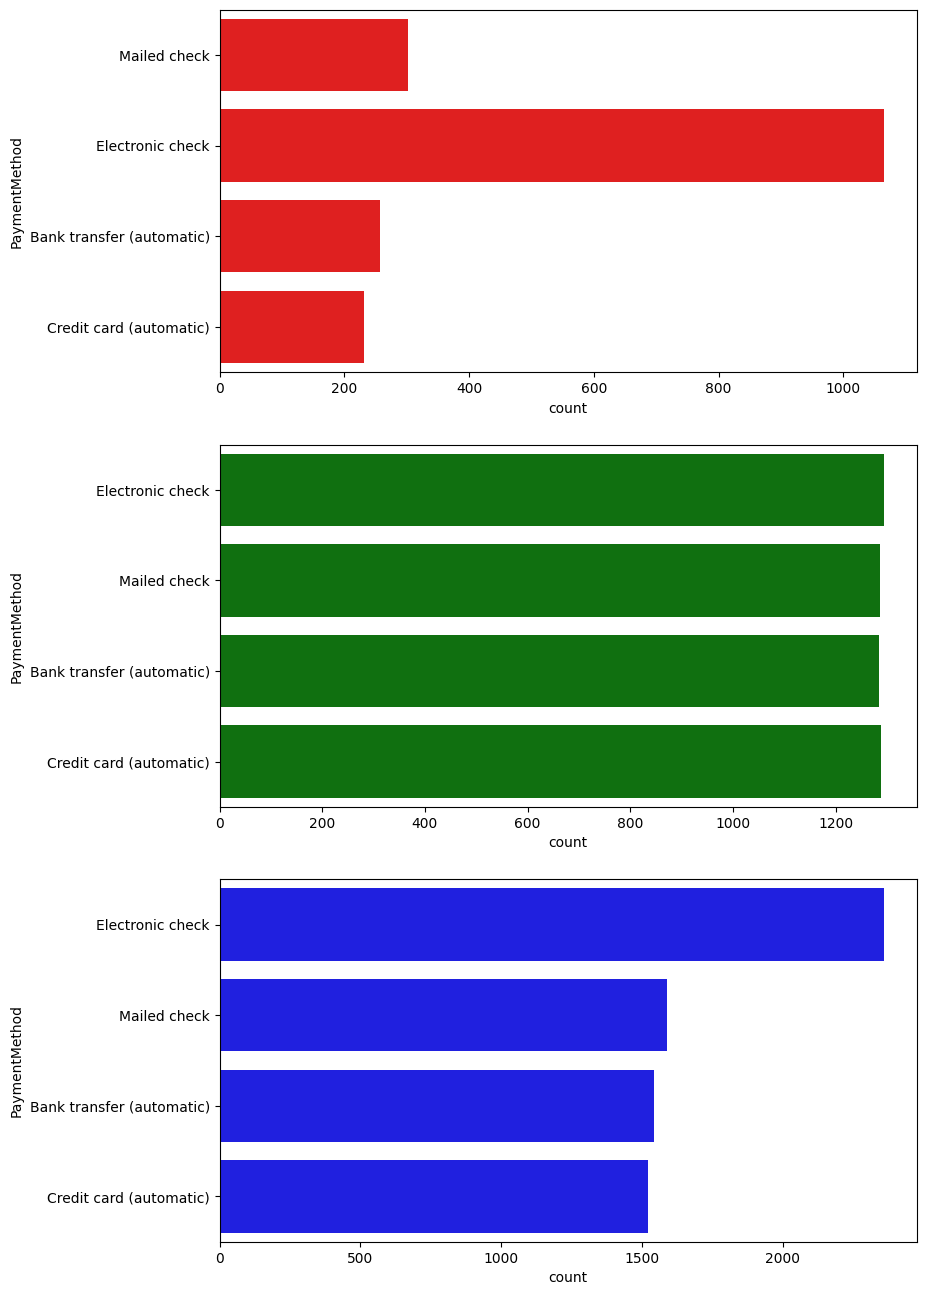

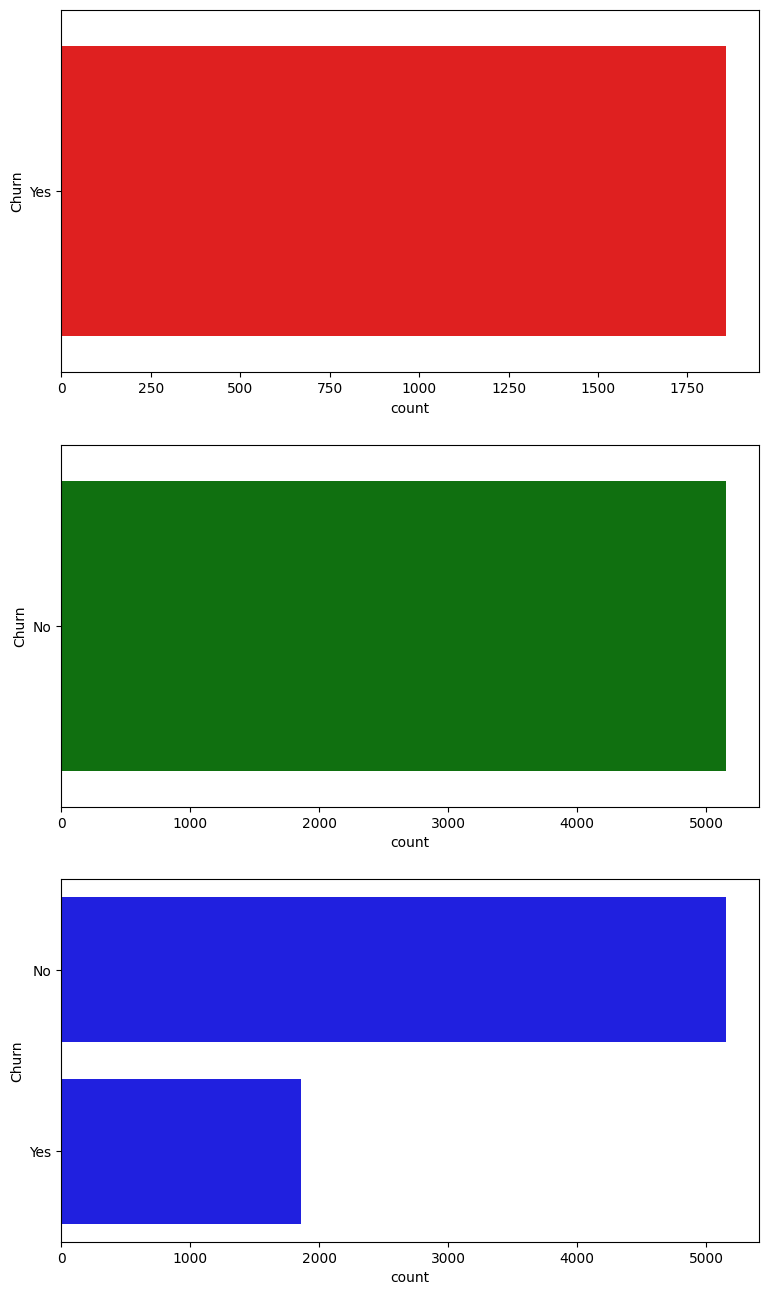

In [23]:

for columns in df.columns:
    if df[columns].dtype != "object":
        continue
    plt.figure(figsize=(9,16))
    plt.subplot(311)
    sns.countplot(y=df[df["Churn"]=="Yes"][columns], color="red")
    plt.subplot(312)
    sns.countplot(y=df[df["Churn"]=="No"][columns], color="green")
    plt.subplot(313)
    sns.countplot(y=df[columns], color="blue")
    plt.show()
# 19.7s 37.8s 24.9s, 13.1s, 11.5s 

> Conclusions
- People with partners have lesser churn rate than the people without partner.
- Customer with dependent have lesser churn than the people with dependents
- Customers with multiple line have higher churn than the customer with no multiple lines.
- people with No Internet service has the least churn followed by DSL and fiber optics being the most churned
- Customer opted for Online Security service, Online Bcakup Service, Device Protection Service and Tech Support have a lower churn rate 
- customer with streaming services have a bit lower churn rate
- Customers with two year contract have very less cchurn followed by one year contract while month to month being the most uncertain having higher churn rate.
- customer having no paper less billing have lower churn.
- electronic check payment method has the highest churn among all the payment method
- these perceptioon are made according to the perception of an individual and it can vary from person to person having domain expertise. 

In [24]:
pd.crosstab(df["Churn"], df["Partner"])

Partner,No,Yes
Churn,,
No,2429,2724
Yes,1188,669


<Axes: xlabel='tenure', ylabel='Proportion'>

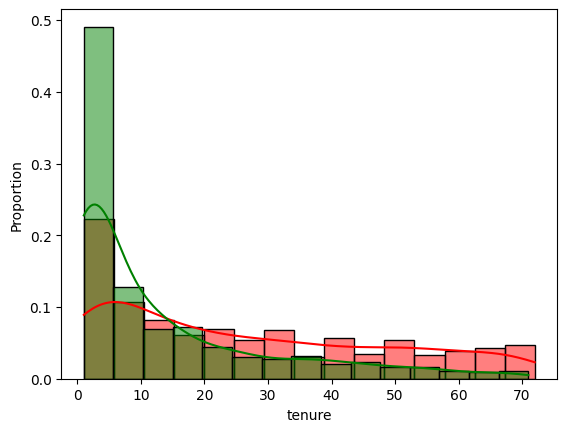

In [25]:
sns.histplot(df[(df["Churn"]=="Yes") & (df["Partner"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["Partner"]=="No")]["tenure"], kde=True, stat="proportion", color="green", bins=15)

In [26]:
df[(df["Churn"]=="Yes") & (df["Partner"]=="Yes") & (df["tenure"]<=5)].shape[0]/df[(df["Churn"]=="Yes") & (df["Partner"]=="Yes")].shape[0]*100

22.27204783258595

In [27]:
df[(df["Churn"]=="Yes") & (df["Partner"]=="No") & (df["tenure"]<=5)].shape[0]/df[(df["Churn"]=="Yes") & (df["Partner"]=="No")].shape[0]*100

49.074074074074076

people with no partner have relatively high churn rate in tenure <= 5 almost 50% churn rate belongs there
whereas people with partner doesn't show any significant difference in churn rate in varying ranges 

In [28]:
pd.crosstab(df["Churn"], df["Dependents"])

Dependents,No,Yes
Churn,,
No,3380,1773
Yes,1531,326


<Axes: xlabel='tenure', ylabel='Proportion'>

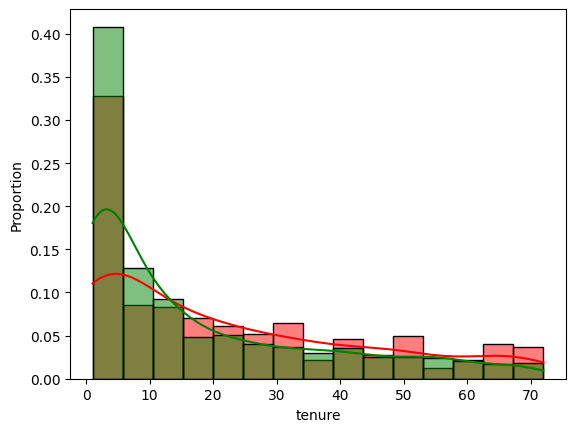

In [29]:
sns.histplot(df[(df["Churn"]=="Yes") & (df["Dependents"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["Dependents"]=="No")]["tenure"], kde=True, stat="proportion", color="green", bins=15)

No major difference is observed in distribution for dependents but people with no dependents are more likely to be churned


In [30]:
pd.crosstab(df["Churn"], df["PhoneService"])

PhoneService,No,Yes
Churn,,
No,510,4643
Yes,170,1687


<Axes: xlabel='tenure', ylabel='Proportion'>

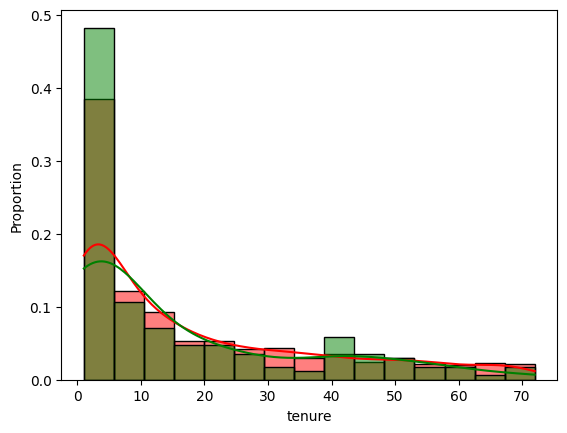

In [31]:
sns.histplot(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No")]["tenure"], kde=True, stat="proportion", color="green", bins=15)

PhoneService doesn't show any major association in data 

In [32]:
pd.crosstab(df["Churn"], df["MultipleLines"])

MultipleLines,No,No phone service,Yes
Churn,,,
No,2526,510,2117
Yes,837,170,850


<Axes: xlabel='tenure', ylabel='Proportion'>

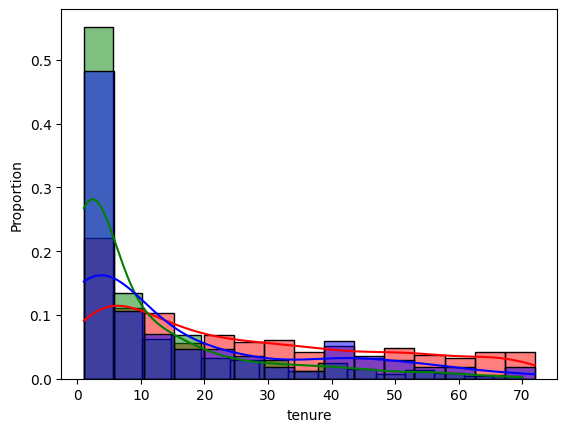

In [33]:
sns.histplot(df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="No")]["tenure"], kde=True, stat="proportion", color="green", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="No phone service")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)

In [34]:
df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="Yes") & (df["tenure"]<10)].shape[0]/df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="Yes")].shape[0]*100

30.470588235294116

In [35]:
df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="No") & (df["tenure"]<10)].shape[0]/df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="No")].shape[0]*100

66.42771804062126

In [36]:
df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="No phone service") & (df["tenure"]<10)].shape[0]/df[(df["Churn"]=="Yes") & (df["MultipleLines"]=="No phone service")].shape[0]*100

56.470588235294116

more than half of churn rate belongs to the tenure<10 for people having no multiple lines or no phone service 

In [37]:
pd.crosstab(df["Churn"], df["InternetService"])

InternetService,DSL,Fiber optic,No
Churn,,,
No,1957,1799,1397
Yes,457,1291,109


<Axes: xlabel='tenure', ylabel='Proportion'>

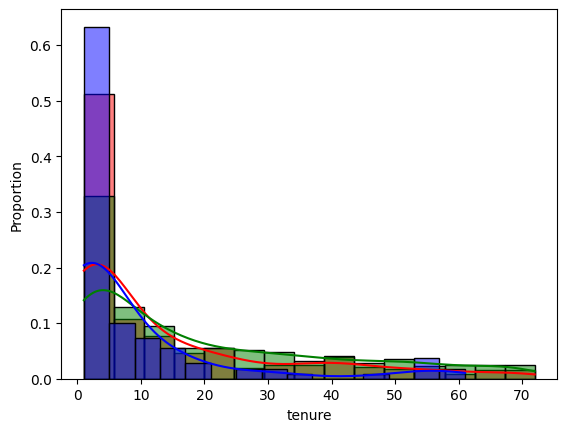

In [38]:
sns.histplot(df[(df["Churn"]=="Yes") & (df["InternetService"]=="DSL")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["InternetService"]=="Fiber optic")]["tenure"], kde=True, stat="proportion", color="green", bins=15)
sns.histplot(df[(df["Churn"]=="Yes") & (df["InternetService"]=="No")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)

In [39]:
df[(df["Churn"]=="Yes") & (df["InternetService"]=="No") & (df["tenure"]<=5)].shape[0]/df[(df["Churn"]=="Yes") & (df["InternetService"]=="No")].shape[0]*100

66.97247706422019

In [40]:
df[(df["Churn"]=="Yes") & (df["InternetService"]=="No") & (df["tenure"]<=10)].shape[0]/df[(df["Churn"]=="Yes") & (df["InternetService"]=="No")].shape[0]*100

75.22935779816514

In [41]:
df[(df["Churn"]=="Yes") & (df["InternetService"]=="DSL") & (df["tenure"]<=5)].shape[0]/df[(df["Churn"]=="Yes") & (df["InternetService"]=="DSL")].shape[0]*100

51.203501094091905

In [42]:
df[(df["Churn"]=="Yes") & (df["InternetService"]=="Fiber optic") & (df["tenure"]<=5)].shape[0]/df[(df["Churn"]=="Yes") & (df["InternetService"]=="Fiber optic")].shape[0]*100

32.92021688613478

- more than 60% churn for No Internet Service and more than 50% churn of DSL customer belongs to tenure <= 5 
- about 75% churn rate belongs to tenure<10 for no internet service
- While Fiber optic have highest churn rate for Internet service

In [43]:
pd.crosstab(df["Churn"], df["OnlineSecurity"])

OnlineSecurity,No,No internet service,Yes
Churn,,,
No,2036,1397,1720
Yes,1453,109,295


<Axes: xlabel='tenure', ylabel='Proportion'>

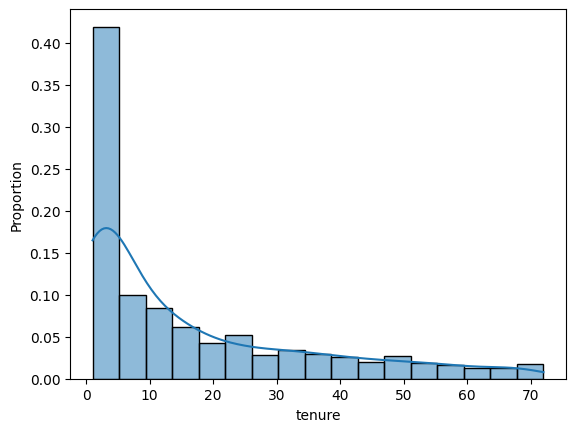

In [44]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["OnlineSecurity"]=="No")]["tenure"], kde=True, stat="proportion")

In [45]:
df[(df["Churn"]=="Yes") & (df["OnlineSecurity"]=="No") & (df["tenure"]<=10)].shape[0]/df[(df["Churn"]=="Yes") & (df["OnlineSecurity"]=="No")].shape[0]*100

54.57673778389539

people with no Online security has higjest churn rate and more than half of the churn belongs to tenure<10

people with online security has lowest churn rate


In [46]:
pd.crosstab(df["Churn"], df["OnlineBackup"])

OnlineBackup,No,No internet service,Yes
Churn,,,
No,1854,1397,1902
Yes,1225,109,523


<Axes: xlabel='tenure', ylabel='Proportion'>

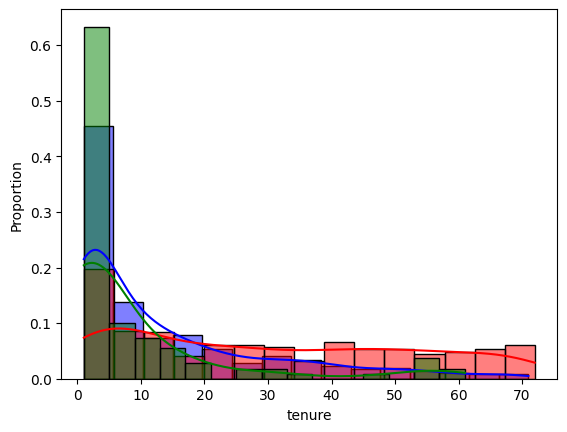

In [47]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["OnlineBackup"]=="No")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["OnlineBackup"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["OnlineBackup"]=="No internet service")]["tenure"], kde=True, stat="proportion", color="green", bins=15)


- people with lesser tenure have higher churn rate for no online backup and people with online backup have relatively lower churn rate for lower tenure but in the higher tenure ranges the proportion of people with online backup shows its almost constant like there is very less fluctuation for tenure > 10

In [48]:
pd.crosstab(df["Churn"], df["DeviceProtection"])

DeviceProtection,No,No internet service,Yes
Churn,,,
No,1883,1397,1873
Yes,1203,109,545


<Axes: xlabel='tenure', ylabel='Proportion'>

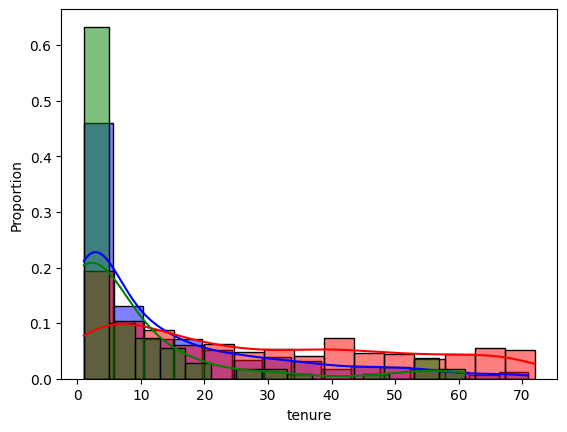

In [49]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["DeviceProtection"]=="No")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["DeviceProtection"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["DeviceProtection"]=="No internet service")]["tenure"], kde=True, stat="proportion", color="green", bins=15)


Device protection similar

In [50]:
pd.crosstab(df["Churn"], df["TechSupport"])

TechSupport,No,No internet service,Yes
Churn,,,
No,2026,1397,1730
Yes,1438,109,310


<Axes: xlabel='tenure', ylabel='Proportion'>

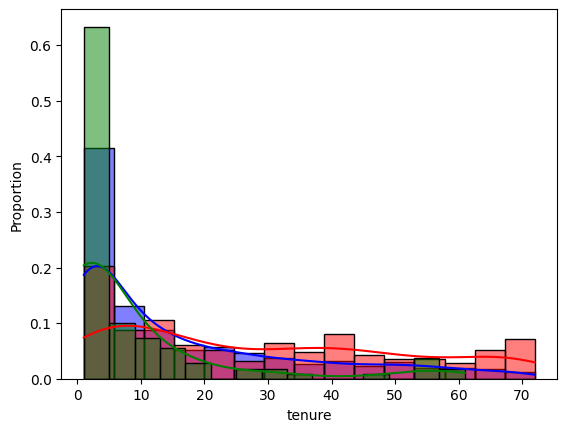

In [51]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["TechSupport"]=="No")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["TechSupport"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["TechSupport"]=="No internet service")]["tenure"], kde=True, stat="proportion", color="green", bins=15)


Tech Support similar behaviour as OnlineBackup and Device protection


In [52]:
pd.crosstab(df["Churn"], df["StreamingTV"])

StreamingTV,No,No internet service,Yes
Churn,,,
No,1867,1397,1889
Yes,934,109,814


<Axes: xlabel='tenure', ylabel='Proportion'>

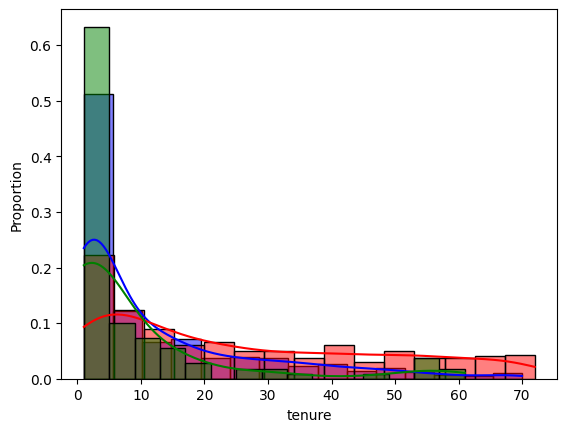

In [53]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["StreamingTV"]=="No")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["StreamingTV"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["StreamingTV"]=="No internet service")]["tenure"], kde=True, stat="proportion", color="green", bins=15)


Streaming TV similar behaviour as OnlineBackup, Device protection and Tech Support 


In [54]:
pd.crosstab(df["Churn"], df["StreamingMovies"])

StreamingMovies,No,No internet service,Yes
Churn,,,
No,1843,1397,1913
Yes,930,109,818


<Axes: xlabel='tenure', ylabel='Proportion'>

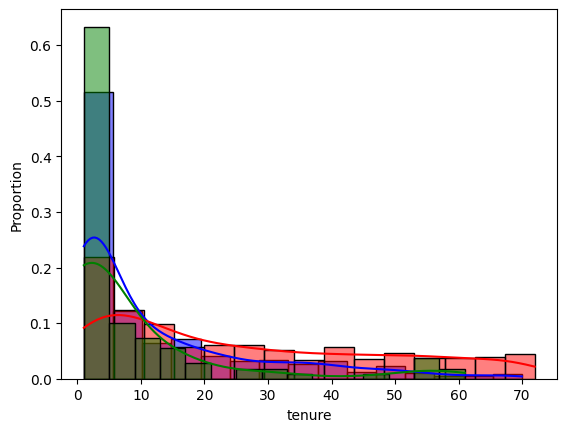

In [55]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["StreamingMovies"]=="No")]["tenure"], kde=True, stat="proportion", color="blue", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["StreamingMovies"]=="Yes")]["tenure"], kde=True, stat="proportion", color="red", bins=15)
sns.histplot(df[(df["Churn"]=="Yes")&(df["StreamingMovies"]=="No internet service")]["tenure"], kde=True, stat="proportion", color="green", bins=15)


Streaming Movies shows similar behavious as Streaming TV

---
---

In [56]:
pd.crosstab(df["Churn"], df["Contract"])

Contract,Month-to-month,One year,Two year
Churn,,,
No,2210,1306,1637
Yes,1643,166,48


<Axes: xlabel='tenure', ylabel='Proportion'>

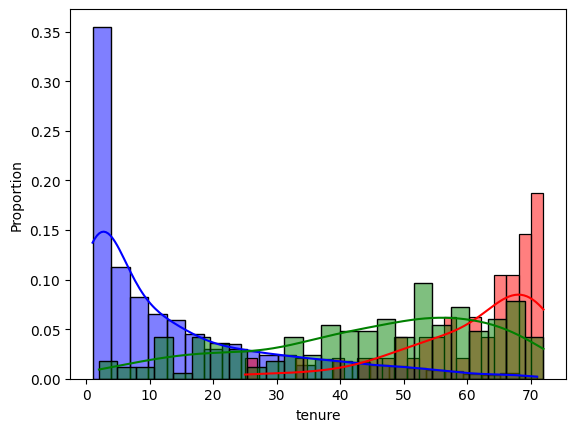

In [57]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"], kde=True, stat="proportion", color="blue", bins=24)
sns.histplot(df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["tenure"], kde=True, stat="proportion", color="red", bins=24)
sns.histplot(df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"], kde=True, stat="proportion", color="green", bins=24)


In [58]:
df["tenure"].max(), df["tenure"].min()

(np.int64(72), np.int64(1))

In [59]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["tenure"].describe()

count    48.000000
mean     61.270833
std      11.004331
min      25.000000
25%      55.750000
50%      65.500000
75%      70.000000
max      72.000000
Name: tenure, dtype: float64

In [60]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["tenure"].quantile(0.05)

np.float64(40.4)

In [61]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["tenure"].quantile(0.95)

np.float64(72.0)

In [62]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["tenure"].count(),df[(df["Contract"]=="Two year")]["tenure"].count()

(np.int64(48), np.int64(1685))

In [63]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["tenure"].count()/df[(df["Contract"]=="Two year")]["tenure"].count()*100

np.float64(2.8486646884272995)

In [64]:
ranges = list(range(0,73,12))
dictionary=dict()
i=0

while(i<len(ranges)-1):
    dictionary[ranges[i+1]]=(df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")&(df["tenure"]>ranges[i])&(df["tenure"]<=ranges[i+1])]["tenure"].count()/df[(df["Contract"]=="Two year")]["tenure"].count()*100)
    i+=1

dictionary

{12: np.float64(0.0),
 24: np.float64(0.0),
 36: np.float64(0.11869436201780414),
 48: np.float64(0.2373887240356083),
 60: np.float64(0.6528189910979229),
 72: np.float64(1.8397626112759646)}

---


In [65]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"].describe()

count    1643.000000
mean       14.111990
std        15.847042
min         1.000000
25%         2.000000
50%         8.000000
75%        21.500000
max        71.000000
Name: tenure, dtype: float64

In [66]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"].quantile(0.05)

np.float64(1.0)

In [67]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month") & (df["tenure"]<=1)]["tenure"].count()/df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"].count()*100

np.float64(22.398052343274497)

In [68]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month") & (df["tenure"]<=1)]["tenure"].count()/df[(df["Contract"]=="Month-to-month")]["tenure"].count()*100

np.float64(9.550999221385933)

In [69]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"].quantile(0.95)

np.float64(49.0)

In [70]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"].count()/df[(df["Contract"]=="Month-to-month")]["tenure"].count()*100

np.float64(42.64209706722035)

In [71]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["tenure"].count(),df[(df["Contract"]=="Month-to-month")]["tenure"].count()

(np.int64(1643), np.int64(3853))

---

In [72]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].describe()

count    166.000000
mean      44.963855
std       18.367261
min        2.000000
25%       33.000000
50%       48.000000
75%       59.000000
max       72.000000
Name: tenure, dtype: float64

In [73]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].quantile(0.05)

np.float64(12.0)

In [74]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].quantile(0.95)

np.float64(69.0)

In [75]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].count(),df[(df["Contract"]=="One year")]["tenure"].count()

(np.int64(166), np.int64(1472))

In [76]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].count()/df[(df["Contract"]=="One year")]["tenure"].count()*100

np.float64(11.277173913043478)

In [77]:
11.27717*0.12

1.3532604

In [78]:
ranges = list(range(0,73,12))
dictionary=dict()
i=0

while(i<len(ranges)-1):
    dictionary[ranges[i+1]]=(df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")&(df["tenure"]>ranges[i])&(df["tenure"]<=ranges[i+1])]["tenure"].count()/df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].count()*100)
    i+=1

dictionary

{12: np.float64(7.83132530120482),
 24: np.float64(9.63855421686747),
 36: np.float64(12.048192771084338),
 48: np.float64(21.084337349397593),
 60: np.float64(26.506024096385545),
 72: np.float64(22.89156626506024)}

In [79]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")&(df["tenure"]<12)]["tenure"].count()/df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["tenure"].count()*100

np.float64(4.819277108433735)

_tenure belongs to [0,72]_

#### Contract: Month-to-month
- About 42% customer gets churned in Month-to-month level contract.
- Out of all churned month-to-month customers, 22% churned in Month 1.
- Out of the total month-to-month customer base, 9% churned in Month 1.
- Out of all churned month-to-month customers, 95% churned before Month 49. so, there is very low churn after 49th month.
- Most of the churn happen before 21 month tenure with 75% of churned proportion.


#### Contract: One year

- About 11% customer gets churned in One year level contract.
- Out of all Churned One year customers, About 26% churned in the months (48, 60]. which is the most if compared for every 6 months.
- Out of total One year customer base, About 3% customer churned in the months (48, 60]. which is lesser when compared to majority class of Month-to-month customers.
- Out of all Churned One year Customer, 5% customers churned before 12 months. so, there is very low churn before 12 months.
- Out of all Churned One year customer, 95% customer churned before 69th month.
- half of the all churned One year customers, churned before 48months 
- most of the churn happen before 59 months tenure with 75% of churned proportion

#### Contract: Two year
- About 3% customer gets churned in Two year level contract.
- Out of all Churned two year customers, About 64% churned in the months (60,72].
- Out of total two year customer base, About 1.8% customers churned in the months (60,72]. which is lowest among all contracts.
- Out of all Churned two year Customer, 5% customers churned uptill 40 months. so, there is extremely low churn before 40 months.
- the churned customer majorily lie near upper bound of tenure. showing left skewness.


> 88.5% churned customers are from Month-to-month Contract, 9% from one year contract, 2.5% from two year contract

In [80]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

---
---

In [81]:
estimateRent = df["MonthlyCharges"].values*df["tenure"].values

In [82]:
estimateRent

array([  29.85, 1936.3 ,  107.7 , ...,  325.6 ,  297.6 , 6972.9 ],
      shape=(7010,))

In [83]:
from sklearn.metrics import root_mean_squared_error



In [84]:
root_mean_squared_error(df["TotalCharges"], estimateRent)

67.35616476524643

negligible error for the data spread

<Axes: ylabel='TotalCharges'>

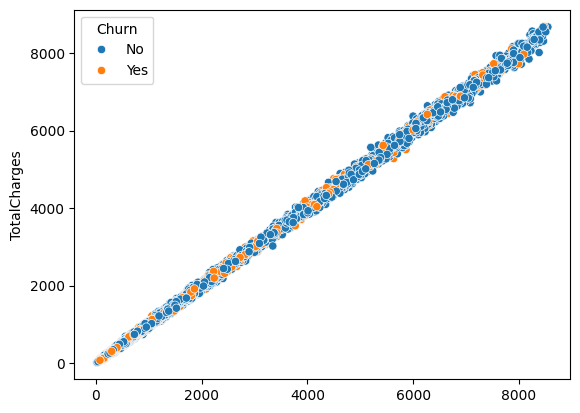

In [85]:
sns.scatterplot(x=estimateRent,y=df["TotalCharges"], hue=df["Churn"])

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

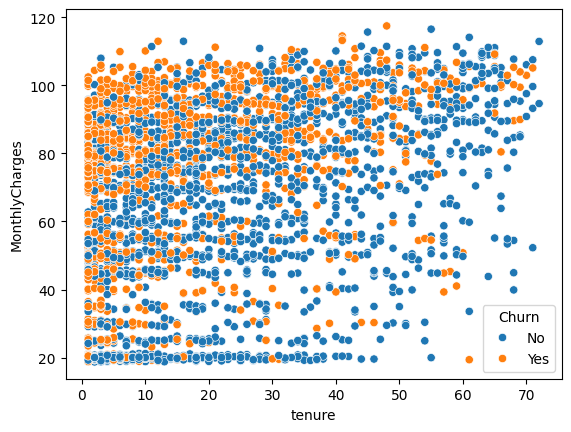

In [86]:
sns.scatterplot(x=df[df["Contract"]=="Month-to-month"]["tenure"], y=df[df["Contract"]=="Month-to-month"]["MonthlyCharges"], hue=df[df["Contract"]=="Month-to-month"]["Churn"])

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

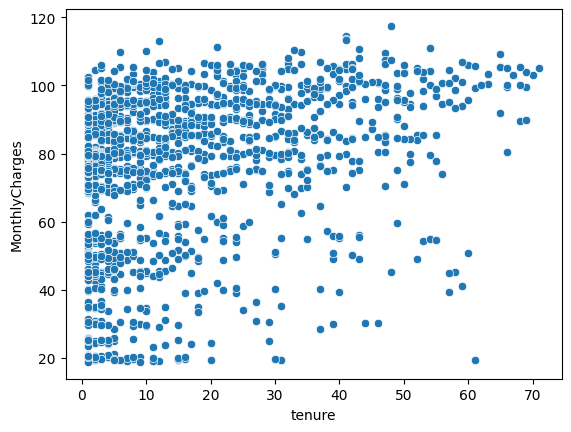

In [87]:

sns.scatterplot(x=df[(df["Contract"]=="Month-to-month")&(df["Churn"]=="Yes")]["tenure"], y=df[(df["Contract"]=="Month-to-month")&(df["Churn"]=="Yes")]["MonthlyCharges"],)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

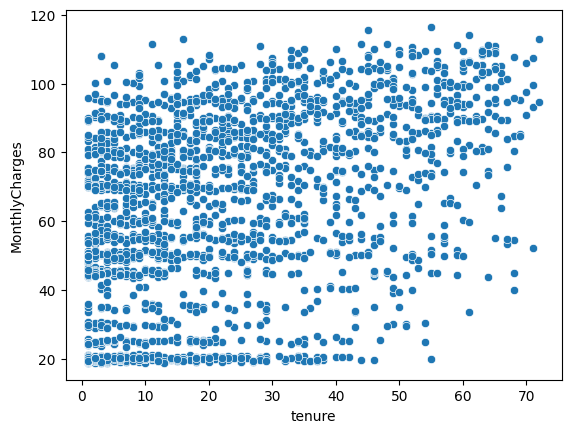

In [88]:
# sns.scatterplot(x=df[df["Contract"]=="Month-to-month"]["tenure"], y=df[df["Contract"]=="Month-to-month"]["MonthlyCharges"], hue=df[df["Contract"]=="Month-to-month"]["Churn"])
sns.scatterplot(x=df[(df["Contract"]=="Month-to-month")&(df["Churn"]=="No")]["tenure"], y=df[(df["Contract"]=="Month-to-month")&(df["Churn"]=="No")]["MonthlyCharges"],)

In [89]:
df[["MonthlyCharges", "tenure"]].describe()

,MonthlyCharges,tenure
count,7010.000000,7010.000000
mean,64.888666,32.520399
std,30.064769,24.520441
min,18.250000,1.000000
25%,35.750000,9.000000
50%,70.400000,29.000000
75%,89.900000,56.000000
max,118.750000,72.000000


In [90]:
tenureLess10 = df[df["tenure"]<10]

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

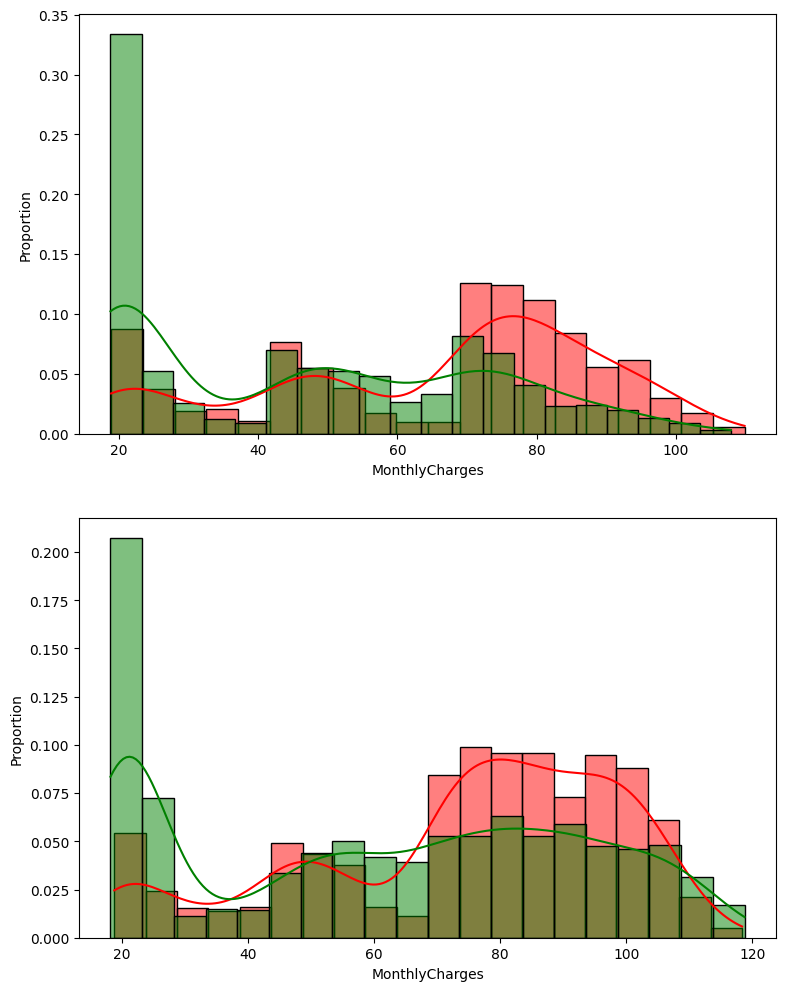

In [91]:
plt.figure(figsize=(9,12))
plt.subplot(211)
sns.histplot(tenureLess10[tenureLess10["Churn"]=="Yes"]["MonthlyCharges"], kde=True, color="red", bins=20, stat="proportion")
sns.histplot(tenureLess10[tenureLess10["Churn"]=="No"]["MonthlyCharges"], kde=True, color="green", bins=20, stat="proportion")
plt.subplot(212)
sns.histplot(df[df["Churn"]=="Yes"]["MonthlyCharges"], kde=True, color="red", bins=20, stat="proportion")
sns.histplot(df[df["Churn"]=="No"]["MonthlyCharges"], kde=True, color="green", bins=20, stat="proportion")

<Axes: xlabel='tenure', ylabel='Proportion'>

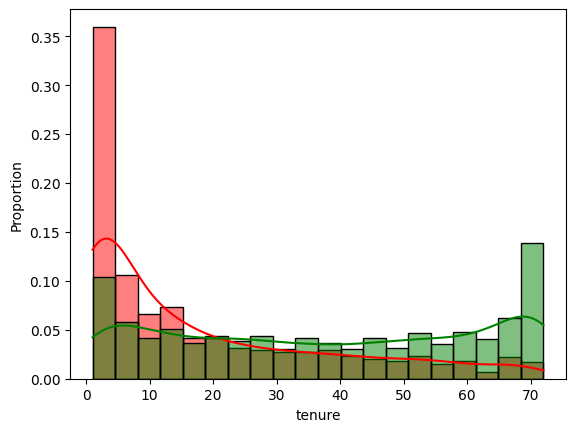

In [92]:

sns.histplot(df[df["Churn"]=="Yes"]["tenure"], kde=True, color="red", bins=20, stat="proportion")
sns.histplot(df[df["Churn"]=="No"]["tenure"], kde=True, color="green", bins=20, stat="proportion")

<Axes: xlabel='TotalCharges', ylabel='Proportion'>

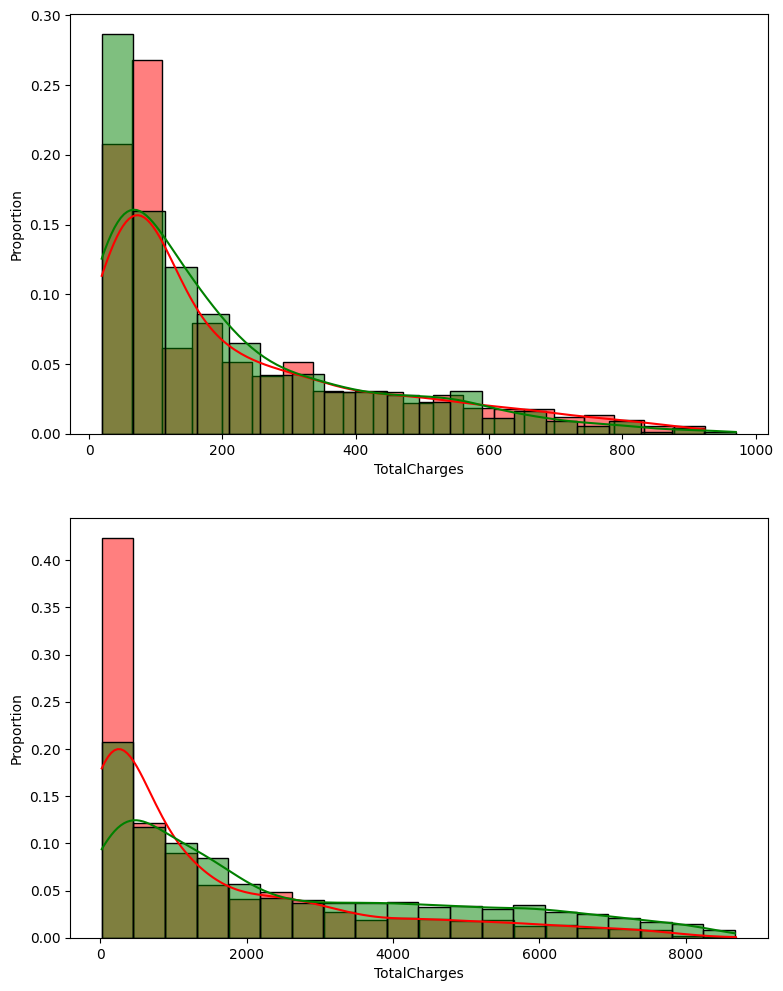

In [93]:
plt.figure(figsize=(9,12))
plt.subplot(211)
sns.histplot(tenureLess10[tenureLess10["Churn"]=="Yes"]["TotalCharges"], kde=True, color="red", bins=20, stat="proportion")
sns.histplot(tenureLess10[tenureLess10["Churn"]=="No"]["TotalCharges"], kde=True, color="green", bins=20, stat="proportion")
plt.subplot(212)
sns.histplot(df[df["Churn"]=="Yes"]["TotalCharges"], kde=True, color="red", bins=20, stat="proportion")
sns.histplot(df[df["Churn"]=="No"]["TotalCharges"], kde=True, color="green", bins=20, stat="proportion",)


In [94]:
ranges = list(range(0,121,10))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[df["Churn"]=="Yes"]["MonthlyCharges"].count()*100
    i+=1
diction

{10: np.float64(0.0),
 20: np.float64(3.12331717824448),
 30: np.float64(5.385029617662897),
 40: np.float64(2.8002154011847065),
 50: np.float64(7.808292945611201),
 60: np.float64(6.946688206785137),
 70: np.float64(5.815831987075929),
 80: np.float64(19.332256327409798),
 90: np.float64(18.093699515347332),
 100: np.float64(17.070543887991384),
 110: np.float64(12.116316639741518),
 120: np.float64(1.5078082929456111)}

In [95]:
ranges = list(range(0,73,12))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["tenure"]<=ranges[i+1])&((df["tenure"]>ranges[i]))]["tenure"].count()/df[df["Churn"]=="Yes"]["tenure"].count()*100
    i+=1
diction

{12: np.float64(55.1965535810447),
 24: np.float64(15.831987075928918),
 36: np.float64(9.693053311793214),
 48: np.float64(7.808292945611201),
 60: np.float64(6.462035541195476),
 72: np.float64(5.008077544426494)}

- for monthly charges from 70 to 110 the churn rate of customers is unusually high as shown: 70-80:19.33% , 80-90: 18.09% ,90-100: 17.07% ,100-110: 12.11%.
- for lower monthly charges the churn rate is relatively  lower if compared to non churned customers.
- for lower tenure there is a very high churn rate, about 55% of churned customer churned before 12 months.
- for higher end of tenure about 60 to 72 months the churn rate is very low if compared to not churned cutomers.
- for lower end of total charges churn rate is very high where tenure have higher association. whereas lower tenure about less than 10 we have very sensitive region between (0<Totalcharges<100), where for 0 to 40 total charges we have lower churn rate as compared to non churned proportion and for 40 to 80 we have higher churn rate than non churned proportion

---
---

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

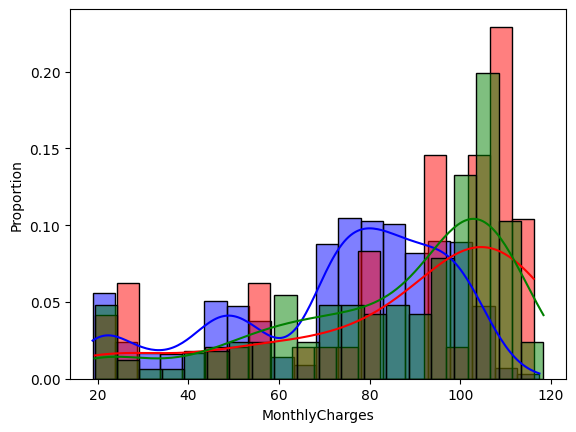

In [146]:
sns.histplot(df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["MonthlyCharges"], kde=True, stat="proportion", color="blue", bins=20)
sns.histplot(df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["MonthlyCharges"], kde=True, stat="proportion", color="red", bins=20)
sns.histplot(df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["MonthlyCharges"], kde=True, stat="proportion", color="green", bins=20)


<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

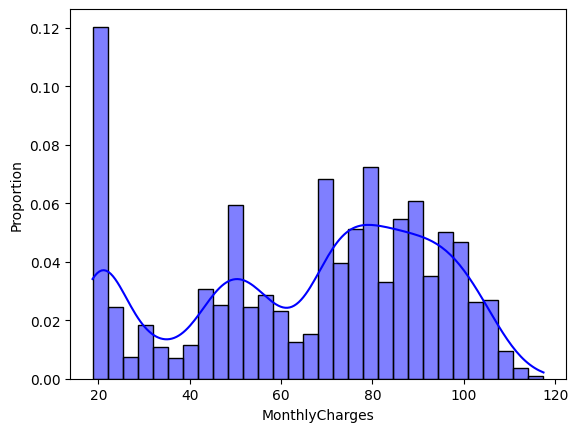

In [97]:
sns.histplot(df[(df["Contract"]=="Month-to-month")]["MonthlyCharges"], kde=True, stat="proportion", color="blue", bins=30)

In [98]:
df[(df["Contract"]=="Month-to-month")]["MonthlyCharges"].describe()

count    3853.000000
mean       66.572203
std        26.853963
min        18.750000
25%        46.000000
50%        73.550000
75%        89.000000
max       117.450000
Name: MonthlyCharges, dtype: float64

In [99]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["MonthlyCharges"].describe()

count    1643.000000
mean       73.193214
std        24.011057
min        18.850000
25%        55.275000
50%        79.150000
75%        91.050000
max       117.450000
Name: MonthlyCharges, dtype: float64

In [100]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["MonthlyCharges"].count()/df[df["Contract"]=="Month-to-month"]["MonthlyCharges"].count()*100

np.float64(42.64209706722035)

In [101]:
ranges = list(range(15,121,5))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["MonthlyCharges"].count()*100
    i+=1
diction

{20: np.float64(3.164942178940962),
 25: np.float64(3.5301278149726114),
 30: np.float64(2.008520998174072),
 35: np.float64(1.5216068167985393),
 40: np.float64(1.5216068167985393),
 45: np.float64(2.982349360925137),
 50: np.float64(5.295191722458917),
 55: np.float64(4.443091905051735),
 60: np.float64(2.6171637248934876),
 65: np.float64(1.0955569080949483),
 70: np.float64(4.686548995739501),
 75: np.float64(10.46865489957395),
 80: np.float64(10.164333536214244),
 85: np.float64(9.555690809494827),
 90: np.float64(9.799147900182593),
 95: np.float64(8.399269628727938),
 100: np.float64(8.88618381010347),
 105: np.float64(6.816798539257456),
 110: np.float64(2.4345709068776626),
 115: np.float64(0.5477784540474742),
 120: np.float64(0.06086427267194157)}

In [102]:
ranges = list(range(15,121,5))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[(df["Contract"]=="Month-to-month")&(df["MonthlyCharges"]<=ranges[i+1])&(df["MonthlyCharges"]>ranges[i])]["MonthlyCharges"].count()*100
    i+=1
diction

{20: np.float64(20.8),
 25: np.float64(21.09090909090909),
 30: np.float64(32.038834951456316),
 35: np.float64(37.878787878787875),
 40: np.float64(46.2962962962963),
 45: np.float64(35.507246376811594),
 50: np.float64(41.0377358490566),
 55: np.float64(32.30088495575221),
 60: np.float64(28.104575163398692),
 65: np.float64(20.0),
 70: np.float64(40.31413612565445),
 75: np.float64(52.59938837920489),
 80: np.float64(55.115511551155116),
 85: np.float64(51.47540983606558),
 90: np.float64(52.78688524590164),
 95: np.float64(48.59154929577465),
 100: np.float64(59.10931174089069),
 105: np.float64(56.28140703517588),
 110: np.float64(40.0),
 115: np.float64(40.909090909090914),
 120: np.float64(33.33333333333333)}

In [103]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["MonthlyCharges"].quantile(0.05)

np.float64(20.605)

In [104]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Month-to-month")]["MonthlyCharges"].quantile(0.95)

np.float64(103.67499999999997)

---

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

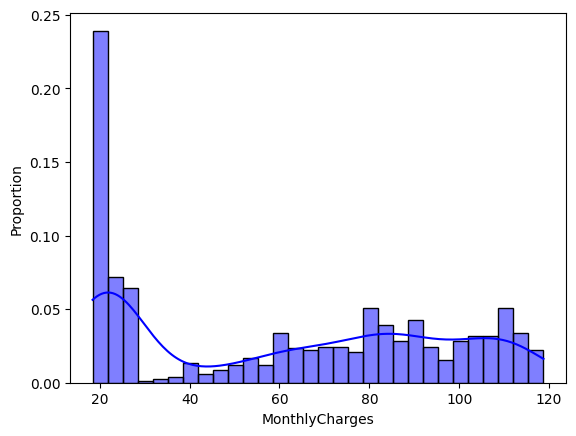

In [105]:
sns.histplot(df[(df["Contract"]=="Two year")]["MonthlyCharges"], kde=True, stat="proportion", color="blue", bins=30)

In [106]:
df[(df["Contract"]=="Two year")]["MonthlyCharges"].describe()

count    1685.000000
mean       60.872374
std        34.712210
min        18.400000
25%        24.050000
50%        64.450000
75%        90.550000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [107]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["MonthlyCharges"].describe()

count     48.000000
mean      86.777083
std       28.917883
min       19.350000
25%       73.650000
50%       97.275000
75%      108.450000
max      116.200000
Name: MonthlyCharges, dtype: float64

In [108]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["MonthlyCharges"].count()/df[df["Contract"]=="Two year"]["MonthlyCharges"].count()*100

np.float64(2.8486646884272995)

In [109]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["MonthlyCharges"].quantile(0.05)

np.float64(24.5875)

In [110]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["MonthlyCharges"].quantile(0.95)

np.float64(113.08)

In [111]:
ranges = list(range(15,121,5))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")]["MonthlyCharges"].count()*100
    i+=1
diction

{20: np.float64(4.166666666666666),
 25: np.float64(4.166666666666666),
 30: np.float64(2.083333333333333),
 35: np.float64(0.0),
 40: np.float64(0.0),
 45: np.float64(0.0),
 50: np.float64(4.166666666666666),
 55: np.float64(4.166666666666666),
 60: np.float64(2.083333333333333),
 65: np.float64(0.0),
 70: np.float64(2.083333333333333),
 75: np.float64(4.166666666666666),
 80: np.float64(4.166666666666666),
 85: np.float64(4.166666666666666),
 90: np.float64(0.0),
 95: np.float64(8.333333333333332),
 100: np.float64(8.333333333333332),
 105: np.float64(8.333333333333332),
 110: np.float64(29.166666666666668),
 115: np.float64(8.333333333333332),
 120: np.float64(2.083333333333333)}

In [112]:
ranges = list(range(15,121,5))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["Contract"]=="Two year")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[(df["Contract"]=="Two year")&(df["MonthlyCharges"]<=ranges[i+1])&(df["MonthlyCharges"]>ranges[i])]["MonthlyCharges"].count()*100
    i+=1
diction

{20: np.float64(0.847457627118644),
 25: np.float64(0.7067137809187279),
 30: np.float64(0.8695652173913043),
 35: np.float64(0.0),
 40: np.float64(0.0),
 45: np.float64(0.0),
 50: np.float64(6.896551724137931),
 55: np.float64(5.714285714285714),
 60: np.float64(1.8867924528301887),
 65: np.float64(0.0),
 70: np.float64(1.5873015873015872),
 75: np.float64(3.571428571428571),
 80: np.float64(2.631578947368421),
 85: np.float64(1.8518518518518516),
 90: np.float64(0.0),
 95: np.float64(5.47945205479452),
 100: np.float64(6.666666666666667),
 105: np.float64(6.349206349206349),
 110: np.float64(13.725490196078432),
 115: np.float64(4.301075268817205),
 120: np.float64(2.127659574468085)}

---

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

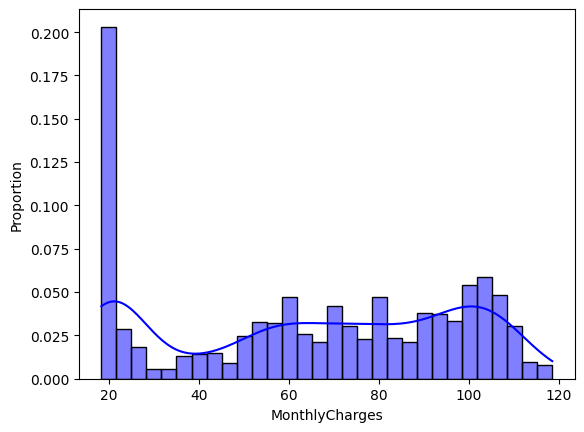

In [113]:
sns.histplot(df[(df["Contract"]=="One year")]["MonthlyCharges"], kde=True, stat="proportion", color="blue", bins=30)

In [114]:
df[(df["Contract"]=="One year")]["MonthlyCharges"].describe()

count    1472.000000
mean       65.079416
std        31.829391
min        18.250000
25%        28.812500
50%        68.750000
75%        94.812500
max       118.600000
Name: MonthlyCharges, dtype: float64

In [115]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["MonthlyCharges"].describe()

count    166.000000
mean      85.050904
std       25.641127
min       19.300000
25%       70.112500
50%       95.050000
75%      104.700000
max      118.350000
Name: MonthlyCharges, dtype: float64

In [116]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["MonthlyCharges"].count()/df[df["Contract"]=="One year"]["MonthlyCharges"].count()*100

np.float64(11.277173913043478)

In [117]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["MonthlyCharges"].quantile(0.05)

np.float64(25.0)

In [118]:
df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["MonthlyCharges"].quantile(0.95)

np.float64(110.8875)

In [119]:
ranges = list(range(15,121,5))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")]["MonthlyCharges"].count()*100
    i+=1
diction

{20: np.float64(2.4096385542168677),
 25: np.float64(3.0120481927710845),
 30: np.float64(0.6024096385542169),
 35: np.float64(1.2048192771084338),
 40: np.float64(0.0),
 45: np.float64(2.4096385542168677),
 50: np.float64(1.8072289156626504),
 55: np.float64(2.4096385542168677),
 60: np.float64(3.614457831325301),
 65: np.float64(4.216867469879518),
 70: np.float64(3.0120481927710845),
 75: np.float64(6.024096385542169),
 80: np.float64(3.614457831325301),
 85: np.float64(4.216867469879518),
 90: np.float64(5.421686746987952),
 95: np.float64(6.024096385542169),
 100: np.float64(9.036144578313253),
 105: np.float64(17.46987951807229),
 110: np.float64(15.66265060240964),
 115: np.float64(5.421686746987952),
 120: np.float64(2.4096385542168677)}

In [120]:
ranges = list(range(15,121,5))
diction=dict()
i=0
while i < len(ranges)-1:
    diction[ranges[i+1]]=df[(df["Churn"]=="Yes")&(df["Contract"]=="One year")&(df["MonthlyCharges"]<=ranges[i+1])&((df["MonthlyCharges"]>ranges[i]))]["MonthlyCharges"].count()/df[(df["Contract"]=="One year")&(df["MonthlyCharges"]<=ranges[i+1])&(df["MonthlyCharges"]>ranges[i])]["MonthlyCharges"].count()*100
    i+=1
diction

{20: np.float64(2.4390243902439024),
 25: np.float64(2.7777777777777777),
 30: np.float64(3.7037037037037033),
 35: np.float64(15.384615384615385),
 40: np.float64(0.0),
 45: np.float64(10.81081081081081),
 50: np.float64(11.538461538461538),
 55: np.float64(5.633802816901409),
 60: np.float64(7.59493670886076),
 65: np.float64(9.333333333333334),
 70: np.float64(8.620689655172415),
 75: np.float64(12.987012987012985),
 80: np.float64(8.0),
 85: np.float64(10.9375),
 90: np.float64(16.363636363636363),
 95: np.float64(11.494252873563218),
 100: np.float64(17.441860465116278),
 105: np.float64(23.770491803278688),
 110: np.float64(25.742574257425744),
 115: np.float64(25.0),
 120: np.float64(28.57142857142857)}

In [121]:
df[(df["Contract"]=="One year")&(df["MonthlyCharges"]<=40)&(df["MonthlyCharges"]>35)]["MonthlyCharges"].count()

np.int64(25)

#### Month-to-month
- customer paying in ranges 18-25 and 60-65 as monthly charges has the least probablity of being churn with the probablity of being churned 20%.
- customer paying 70 to 95 as monthly charges has the higher probablity of being churn with 50% ratio and customer paying in ranges 95 to 105 has the highest probablity of being churn having rate 60%.
- about 95% of customer has been churned uptil monthly charges 104.

#### Two year
- cutomer paying in ranges 30-45, 60-65 and 85-90 as monthly charges has literally no churn  standing with least amount of churn.
- customer paying in range 105 to 110 has the highest probablity of being churned as it shows 13% churn rate.
- customer paying in the range 20-45 as monthly charges has least probablity of being chun as proportion is 0% or near to 0%

#### One Year
- for customer paying 70 to 110 has a higher probablity of leaving the platform about 50% is probablity of being churn in that range. out of all the churn this range contributes the most 70-80 contains 20%, 80-90 contains 19%, 90-100 contains 17% and 100-110 contains 9% of all churned customer
- for customer paying 15-30 and 50-60 has the least probablity of being churn with 20-25% and 30% respectively
- there is literally no churn for the range Monthly charge range 35 to 40 despite having 25 customers in that range

In [122]:
pd.crosstab(df["InternetService"], df["Contract"])

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,1221,570,623
Fiber optic,2122,539,429
No,510,363,633


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

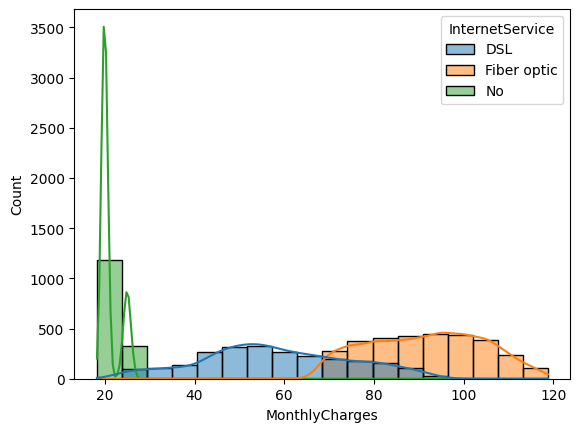

In [123]:
sns.histplot(data=df, x=df["MonthlyCharges"], hue=df["InternetService"], kde=True)

In [124]:
print(df[df["InternetService"]=="Fiber optic"]["MonthlyCharges"].describe())
print(df[df["InternetService"]=="Fiber optic"]["MonthlyCharges"].quantile(0.05))
print(df[df["InternetService"]=="Fiber optic"]["MonthlyCharges"].quantile(0.95))

count    3090.000000
mean       91.542427
std        12.638840
min        67.750000
25%        80.550000
50%        91.725000
75%       101.150000
max       118.750000
Name: MonthlyCharges, dtype: float64
70.3725
111.2


In [125]:
print(df[df["InternetService"]=="DSL"]["MonthlyCharges"].describe())
print(df[df["InternetService"]=="DSL"]["MonthlyCharges"].quantile(0.05))
print(df[df["InternetService"]=="DSL"]["MonthlyCharges"].quantile(0.95))

count    2414.000000
mean       58.098447
std        16.268867
min        23.450000
25%        46.200000
50%        56.150000
75%        69.887500
max        94.800000
Name: MonthlyCharges, dtype: float64
29.8825
85.45


In [147]:
print(df[df["InternetService"]=="No"]["MonthlyCharges"].describe())
print(df[df["InternetService"]=="No"]["MonthlyCharges"].quantile(0.05))
print(df[df["InternetService"]=="No"]["MonthlyCharges"].quantile(0.95))

count    1506.000000
mean       21.084861
std         2.169564
min        18.250000
25%        19.700000
50%        20.150000
75%        20.900000
max        26.900000
Name: MonthlyCharges, dtype: float64
19.2
25.5


- the DSL is ranging between monthly charges 23 to 95 where most of the distribution lies between monthly charges 29 and 86
- the fiber optic is ranging between monthly charges 67 to 119, where most of the distribution lies between 70 and 110 
- the no internet service is ranging between monthly charges 18 to 27 where most of the distribution lies between monthly charges 19 and 26 

In [126]:
monthToMonth = df[df["Contract"]=="Month-to-month"]
oneYear = df[df["Contract"]=="One year"]
twoYear = df[df["Contract"]=="Two year"]

In [127]:
mtmct=pd.crosstab(monthToMonth["InternetService"], monthToMonth["Churn"])
mtmct

Churn,No,Yes
InternetService,,
DSL,829,392
Fiber optic,966,1156
No,415,95


In [128]:
reference=mtmct
num=list()
den=list()
for i in range(reference.shape[0]):
    x=reference.iloc[i, 0]
    y=reference.iloc[i, 1]
    print(y/(x+y)*100)
    num.append(y)
    den.append(x+y)
print((sum(num)/sum(den))*100)


32.104832104832106
54.47690857681433
18.627450980392158
42.64209706722035


In [129]:
oyct=pd.crosstab(oneYear["InternetService"], oneYear["Churn"])
oyct

Churn,No,Yes
InternetService,,
DSL,517,53
Fiber optic,435,104
No,354,9


In [130]:
reference=oyct
num=list()
den=list()
for i in range(reference.shape[0]):
    x=reference.iloc[i, 0]
    y=reference.iloc[i, 1]
    print(y/(x+y)*100)
    num.append(y)
    den.append(x+y)
print((sum(num)/sum(den))*100)

9.298245614035087
19.29499072356215
2.479338842975207
11.277173913043478


In [131]:
tyct=pd.crosstab(twoYear["InternetService"], twoYear["Churn"])
tyct

Churn,No,Yes
InternetService,,
DSL,611,12
Fiber optic,398,31
No,628,5


In [132]:
reference=tyct
num=list()
den=list()
for i in range(reference.shape[0]):
    x=reference.iloc[i, 0]
    y=reference.iloc[i, 1]
    print(y/(x+y)*100)
    num.append(y)
    den.append(x+y)
print((sum(num)/sum(den))*100)

1.9261637239165328
7.226107226107226
0.7898894154818324
2.8486646884272995


- for month to month user the churn rate is 42.64% in which for for DSL 32.1%, for fiber optic 54.48% and for no internet service 18.64% is the churn rate of being churn for respective services in month to month contract
- for One year user the churn rate is 11.28% in which for for DSL 9.3%, for fiber optic 19.29% and for no internet service 2.48% is the churn rate for respective services in One year contract
- for Two year user the churn rate is 2.84% in which for for DSL 1.93%, for fiber optic 7.23% and for no internet service 0.79% is the churn rate for respective services in Two year contract
- no internet service has the lowest churn churn rate followed by dsl while fiber optic being the most churned 
- month to month have highest churn rate followed by one year while Two year contract have lowest churn rate.

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

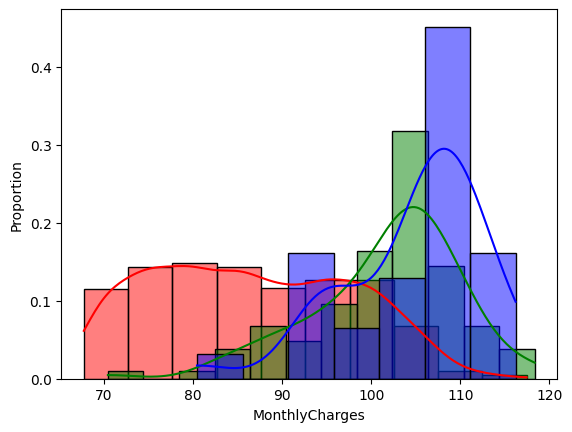

In [133]:
references=df[(df["Churn"]=="Yes")&(df["InternetService"]=="Fiber optic")]
sns.histplot(x=references[references["Contract"]=="Month-to-month"]["MonthlyCharges"], kde=True, color="red", stat="proportion", binwidth=5)
sns.histplot(x=references[references["Contract"]=="One year"]["MonthlyCharges"], kde=True, color="green", stat="proportion")
sns.histplot(x=references[references["Contract"]=="Two year"]["MonthlyCharges"], kde=True, color="blue", stat="proportion")

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

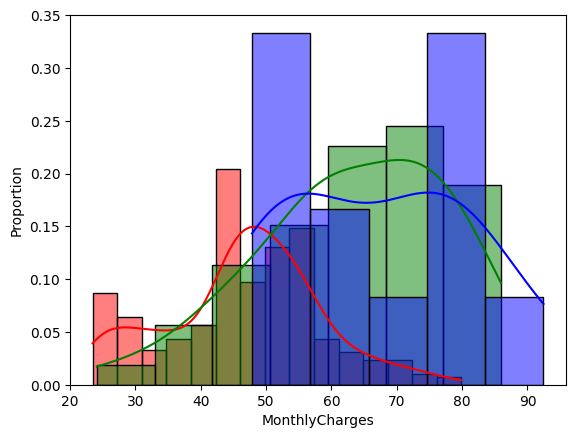

In [134]:
references=df[(df["Churn"]=="Yes")&(df["InternetService"]=="DSL")]
sns.histplot(x=references[references["Contract"]=="Month-to-month"]["MonthlyCharges"], kde=True, color="red", stat="proportion")
sns.histplot(x=references[references["Contract"]=="One year"]["MonthlyCharges"], kde=True, color="green", stat="proportion")
sns.histplot(x=references[references["Contract"]=="Two year"]["MonthlyCharges"], kde=True, color="blue", stat="proportion")

<Axes: xlabel='MonthlyCharges', ylabel='Proportion'>

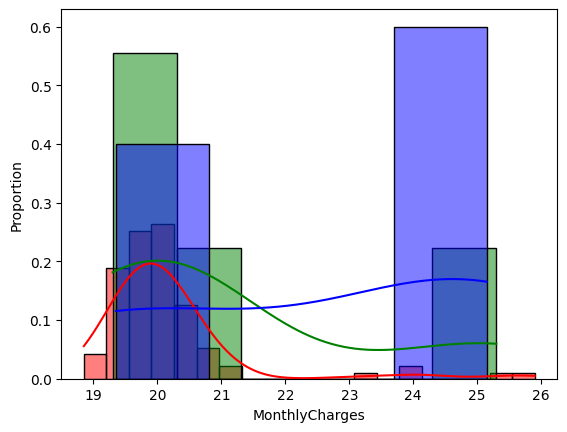

In [135]:
references=df[(df["Churn"]=="Yes")&(df["InternetService"]=="No")]
sns.histplot(x=references[references["Contract"]=="Month-to-month"]["MonthlyCharges"], kde=True, color="red", stat="proportion")
sns.histplot(x=references[references["Contract"]=="One year"]["MonthlyCharges"], kde=True, color="green", stat="proportion")
sns.histplot(x=references[references["Contract"]=="Two year"]["MonthlyCharges"], kde=True, color="blue", stat="proportion")

<Axes: xlabel='tenure', ylabel='Proportion'>

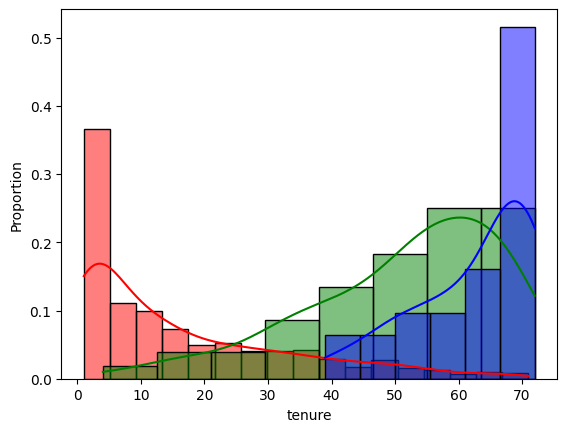

In [136]:
references=df[(df["Churn"]=="Yes")&(df["InternetService"]=="Fiber optic")]
sns.histplot(x=references[references["Contract"]=="Month-to-month"]["tenure"], kde=True, color="red", stat="proportion")
sns.histplot(x=references[references["Contract"]=="One year"]["tenure"], kde=True, color="green", stat="proportion")
sns.histplot(x=references[references["Contract"]=="Two year"]["tenure"], kde=True, color="blue", stat="proportion")

<Axes: xlabel='tenure', ylabel='Proportion'>

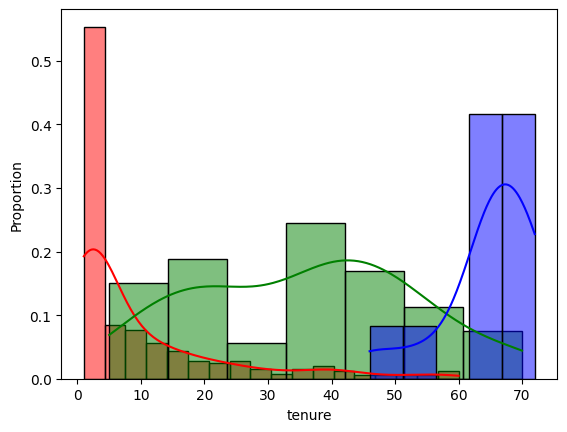

In [137]:
references=df[(df["Churn"]=="Yes")&(df["InternetService"]=="DSL")]
sns.histplot(x=references[references["Contract"]=="Month-to-month"]["tenure"], kde=True, color="red", stat="proportion")
sns.histplot(x=references[references["Contract"]=="One year"]["tenure"], kde=True, color="green", stat="proportion")
sns.histplot(x=references[references["Contract"]=="Two year"]["tenure"], kde=True, color="blue", stat="proportion")

<Axes: xlabel='tenure', ylabel='Proportion'>

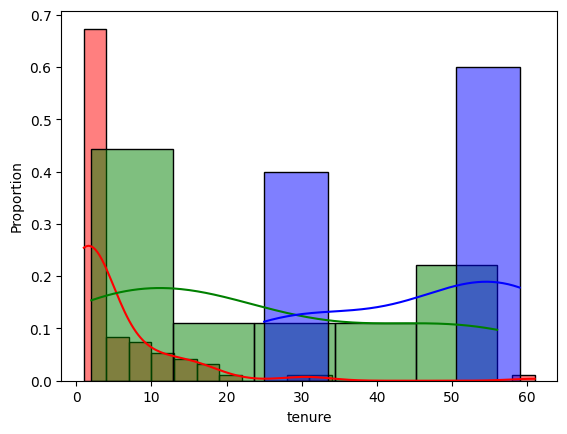

In [138]:
references=df[(df["Churn"]=="Yes")&(df["InternetService"]=="No")]
sns.histplot(x=references[references["Contract"]=="Month-to-month"]["tenure"], kde=True, color="red", stat="proportion")
sns.histplot(x=references[references["Contract"]=="One year"]["tenure"], kde=True, color="green", stat="proportion",)
sns.histplot(x=references[references["Contract"]=="Two year"]["tenure"], kde=True, color="blue", stat="proportion")


- for month to month fiber optic user the proportion of customer churn in churned cutomer is about 10 to 14% each for 65 to 105 monthly charge if taken interval is 5.
- for One year fiber optic user the highest churned customer comes in the monthly charge range 95 to 110.
- for Two year fiber optic user the highest churned customer comes in the monthly charge range 105 to 110.
- for Month-to-month DSL customer we found the distribution more to be towards normal and having most of the churn in the range 40-60 monthly charges.
- for One year DSL customers we found that most of the customer churn comes from the monthly charges 55 to 85
- for no internet service customers, customer with month to month contract churns majorly between 19 to 21 months, customer with one year contract majorly leaves in 20-21 months, customers with two year contract only churned in month 20 ,24 and 25..
- for churned fiber customers month to month contract customers majorly churn in first 20-25 months whereas One year contract customers get churned after 40 months and Two year contract customers majorly churn after 60 months
- for churned DSL customers, customer with month to month contract majorly churns in first 4 months, whereas customer with two year contract majorly churns after 60 months 
- for churned no internet customers, month to month contract customers churns majorly in first 3-4 months, One year contract customer churns majorly in 2-12 months, Two year customer churns in months 54 to 59

In [139]:
pd.crosstab(monthToMonth["Churn"], monthToMonth["PaperlessBilling"])

PaperlessBilling,No,Yes
Churn,,
No,874,1336
Yes,403,1240


In [140]:
pd.crosstab(oneYear["Churn"], oneYear["PaperlessBilling"])

PaperlessBilling,No,Yes
Churn,,
No,625,681
Yes,48,118


In [141]:
pd.crosstab(twoYear["Churn"], twoYear["PaperlessBilling"])

PaperlessBilling,No,Yes
Churn,,
No,887,750
Yes,15,33


In [142]:
pd.crosstab(df["PaymentMethod"], df["PaperlessBilling"])

PaperlessBilling,No,Yes
PaymentMethod,,
Bank transfer (automatic),653,889
Credit card (automatic),639,882
Electronic check,622,1737
Mailed check,938,650


In [143]:
pd.crosstab(df["PaperlessBilling"], df["Churn"])

Churn,No,Yes
PaperlessBilling,,
No,2386,466
Yes,2767,1391


In [144]:
1391/(1391+2767), 466/(466+2386)

(0.3345358345358345, 0.16339410939691446)

- churn rate almost doubles when paperless billing is enabled.
- most of the paperless billing comes under Electronic check payment method.

In [145]:

df[(df["PaperlessBilling"]=="Yes")&(df["PaymentMethod"]=="Electronic check")&(df["Churn"]=="Yes")]["Churn"].count()/df[(df["PaperlessBilling"]=="Yes")&(df["PaymentMethod"]=="Electronic check")]["Churn"].count()

np.float64(0.4962579159470351)

- there is 50% proportion of the data in paperless billing enabled, electronic check payment which is churned which is highest among all available option